# EARLY DETECTION OF LOAN DEFAULT RISK FOR SMES & YOUTH ENTREPRENEURS

## 1. Business Understanding

### 1.1 Problem Context

Small and medium enterprises (SMEs) and youth entrepreneurs in emerging markets face limited access to affordable credit due to high perceived default risk. Manual credit assessments are slow, subjective, and difficult to scale.

This project develops a **supervised machine learning model** to **predict early loan default risk**, enabling lenders to:

    Reduce non-performing loans
    Intervene early with high-risk borrowers
    Promote financial inclusion through fairer credit decisions

### 1.2 Stakeholders
   **Primary**: Credit officers, risk analysts, loan managers

   **Secondary**: SME lenders, fintech product teams, regulators

### 1.3 Objective
Can we predict whether a loan will default using borrower demographics, loan terms, and early repayment behavior?

    Target variable: is_default (0 = non-default, 1 = default)

    Prediction type: Binary classification/Multi_Class

    Prediction timing: Early lifecycle

## 2. Environment Setup

In [1]:
#core library
import pandas as pd
import numpy as np

#visualization 
import seaborn as sns
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style and color scheme
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

COLORS = {
    'default': ['#FF6B6B', '#4ECDC4'],  # Red for default, Teal for non-default
    'sequential': ['#1A2980', '#26D0CE'],
    'categorical': ['#FF9A76', '#FFEAA7', '#BDC581', '#4A69BB', '#6A89CC']
}

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb
#pip install shap==0.44.1
#%pip install lightgbm

#Oversampling
from imblearn.over_sampling import SMOTE

#others to be imported as needed
from scipy import stats

## 3. Data Understanding

### 3.1  Data Overview

The dataset used in this analysis consists of **277,159 loan records** collected from **Micromart Africa’s digital lending platform** for the purpose of **loan default prediction**. It contains several key feature groups, including: **borrower attributes** (e.g., age, gender, and account age), **loan characteristics** (e.g., principal, interest, total loan amount, loan term, product type, and number of installments), and **repayment behavior indicators** (e.g., total amount paid, unpaid balance, days late, and numbers of late and on-time payments).

The dataset is structured as a **binary classification problem**, where the target variable indicates whether a borrower defaulted on a loan. It combines demographic, transactional, and behavioral information, enabling the development of supervised machine learning models for credit risk assessment.


### 3.2  Data Description

### 3.2.1  Importing the dataset

In [2]:
#importing and printing head
data = pd.read_csv("data/loan_dataset.csv")
data.head()

,LoanId,BorrowerId,BorrowDate,target_loan_cleared,is_default,avg_days_late,max_days_late,num_late_payments,num_ontime_payments,num_penalties,...,EntityAgent,AccountStatus,loan_month,loan_quarter,IsRegfeePaid,loan_size_escalation,penalty_rate,days_to_disbursement,IsMatrixApplied,has_collection_agent
0,392911,135130,12/31/2025,1,0,0,0,0,0,0,...,44536,1,12,4,0.0,1.360067,0.0,NaN,NaN,0
1,392906,147149,12/31/2025,1,0,0,0,0,0,0,...,44608,1,12,4,0.0,1.250000,0.0,NaN,NaN,0
2,392898,150329,12/31/2025,1,0,0,0,0,0,0,...,44615,1,12,4,0.0,1.000000,0.0,NaN,NaN,0
3,392763,22060,12/31/2025,1,0,0,0,0,0,0,...,44353,1,12,4,NaN,1.283296,0.0,NaN,NaN,0
4,392713,148157,12/30/2025,1,0,0,0,0,0,0,...,44459,1,12,4,0.0,1.000000,0.0,NaN,NaN,0


### 3.2.2  Basic Structure

In [3]:
#Shape
data.shape

(277158, 50)

In [4]:
#data columns
data.columns

Index(['LoanId', 'BorrowerId', 'BorrowDate', 'target_loan_cleared',
       'is_default', 'avg_days_late', 'max_days_late', 'num_late_payments',
       'num_ontime_payments', 'num_penalties', 'late_payment_rate',
       'repayment_ratio', 'total_overpaid', 'total_unpaid_amount',
       'avg_installment_paid', 'LoanAmount', 'loan_term_days', 'Principal',
       'Interest', 'interest_rate', 'loan_to_limit_ratio', 'ProductId',
       'Loantype', 'IsLoanNew', 'IsRolledOver', 'age', 'Gender',
       'account_age_days', 'GraduationCount', 'LoanLimit', 'PreviousLoanLimit',
       'graduation_velocity', 'previous_loan_count', 'previous_clearance_rate',
       'previous_rollover_count', 'ApprovalStage', 'ChannelUsed',
       'has_guarantor', 'EntityId', 'EntityUnit', 'EntityAgent',
       'AccountStatus', 'loan_month', 'loan_quarter', 'IsRegfeePaid',
       'loan_size_escalation', 'penalty_rate', 'days_to_disbursement',
       'IsMatrixApplied', 'has_collection_agent'],
      dtype='object')

### 3.2.3 Overview of column types and non-null values

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277158 entries, 0 to 277157
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   LoanId                   277158 non-null  int64  
 1   BorrowerId               277158 non-null  int64  
 2   BorrowDate               277158 non-null  object 
 3   target_loan_cleared      277158 non-null  int64  
 4   is_default               277158 non-null  int64  
 5   avg_days_late            277158 non-null  int64  
 6   max_days_late            277158 non-null  int64  
 7   num_late_payments        277158 non-null  int64  
 8   num_ontime_payments      277158 non-null  int64  
 9   num_penalties            277158 non-null  int64  
 10  late_payment_rate        277158 non-null  float64
 11  repayment_ratio          275598 non-null  float64
 12  total_overpaid           277158 non-null  float64
 13  total_unpaid_amount      277158 non-null  float64
 14  avg_

### 3.2.4 Summary statistics

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
LoanId,277158.0,225308.088704,111540.362066,773.000000,133514.500000,247762.50,318023.750000,3.929110e+05
BorrowerId,277158.0,61605.113264,45582.946464,22.000000,17249.000000,66946.00,101160.000000,1.503290e+05
target_loan_cleared,277158.0,0.848642,0.358398,0.000000,1.000000,1.00,1.000000,1.000000e+00
is_default,277158.0,0.195488,0.396576,0.000000,0.000000,0.00,0.000000,1.000000e+00
avg_days_late,277158.0,50.364355,158.487318,-75.000000,0.000000,2.00,9.000000,1.632000e+03
max_days_late,277158.0,95.810945,262.740724,-30.000000,1.000000,7.00,18.000000,1.728000e+03
num_late_payments,277158.0,2.542326,2.803292,0.000000,1.000000,2.00,4.000000,3.700000e+01
num_ontime_payments,277158.0,4.442535,3.037915,0.000000,4.000000,4.00,4.000000,5.000000e+01
num_penalties,277158.0,0.095227,0.696773,0.000000,0.000000,0.00,0.000000,2.500000e+01
late_payment_rate,277158.0,0.478789,0.359075,0.000000,0.166667,0.50,0.750000,1.000000e+00


In [7]:
#borrowdate is an object that should be converted to date format
print(data.describe(include='O'))

data['BorrowDate'] = pd.to_datetime(data['BorrowDate'], errors='coerce')
print(data['BorrowDate'].dtypes)

        BorrowDate
count       277158
unique        1688
top     10/13/2025
freq           470
datetime64[ns]


### 3.2.5  Missing values

In [8]:
data.isna().mean()*100

LoanId                      0.000000
BorrowerId                  0.000000
BorrowDate                 40.809574
target_loan_cleared         0.000000
is_default                  0.000000
avg_days_late               0.000000
max_days_late               0.000000
num_late_payments           0.000000
num_ontime_payments         0.000000
num_penalties               0.000000
late_payment_rate           0.000000
repayment_ratio             0.562856
total_overpaid              0.000000
total_unpaid_amount         0.000000
avg_installment_paid        0.000000
LoanAmount                  0.000722
loan_term_days              0.011185
Principal                   0.000000
Interest                    0.000722
interest_rate               0.000722
loan_to_limit_ratio         0.000722
ProductId                   0.000000
Loantype                   64.920370
IsLoanNew                   9.720809
IsRolledOver               65.667958
age                         3.980762
Gender                      0.009381
a

### 3.2.6  Duplicates

In [9]:
data.duplicated().sum()

0

### 3.2.7  Data Summary

**Dataset Overview**
- **Records:** 277,158 loan observations  
- **Features:** 50 variables  
- **Scope:** Borrower demographics, loan characteristics, repayment behavior, penalties, and operational metadata  

**Structure**
- **Rows × Columns:** 277,158 × 50  
- **Data types:** 28 float, 21 integer, 1 date  
- **Duplicates:** None detected  

**Data Quality**
- Core identifiers and target variable are fully populated, indicating a well-maintained transactional dataset.
- **Demographics:**  
  - Gender missing: **~0.01%**  
  - Age missing: **~4.0%**
- **Repayment & operational variables:**  
  - ChannelUsed missing: **~58.2%**  
  - IsRolledOver missing: **~65.6%**  
  - Loantype missing: **~64.9%**  
  - GraduationCount and PreviousLoanLimit missing: **>99%**  
  - Repayment ratio missing: **~0.6%**

**Target Variable**
- **is_default:** 0% missing (fully reliable for supervised learning)

**Suitability**
- Large-scale, well-structured dataset suitable for **credit risk modeling** and **loan repayment/default prediction**, with rich behavioral, transactional, and borrower-level signals.  


## 4. Data Preparation

### 4.1   Data Cleaning

In [10]:
# Making a copy of the data
df = data.copy()
df.head()

,LoanId,BorrowerId,BorrowDate,target_loan_cleared,is_default,avg_days_late,max_days_late,num_late_payments,num_ontime_payments,num_penalties,...,EntityAgent,AccountStatus,loan_month,loan_quarter,IsRegfeePaid,loan_size_escalation,penalty_rate,days_to_disbursement,IsMatrixApplied,has_collection_agent
0,392911,135130,2025-12-31,1,0,0,0,0,0,0,...,44536,1,12,4,0.0,1.360067,0.0,NaN,NaN,0
1,392906,147149,2025-12-31,1,0,0,0,0,0,0,...,44608,1,12,4,0.0,1.250000,0.0,NaN,NaN,0
2,392898,150329,2025-12-31,1,0,0,0,0,0,0,...,44615,1,12,4,0.0,1.000000,0.0,NaN,NaN,0
3,392763,22060,2025-12-31,1,0,0,0,0,0,0,...,44353,1,12,4,NaN,1.283296,0.0,NaN,NaN,0
4,392713,148157,2025-12-30,1,0,0,0,0,0,0,...,44459,1,12,4,0.0,1.000000,0.0,NaN,NaN,0


### 4.1.1  Standardizing columns: Lower case

In [11]:
df.columns = df.columns.str.lower()

### 4.1.2  Dropping Unnecessary Columns

In [12]:
#Columns to drop
drop_cols = [
    "loanid", "borrowerid",
    "entityid", "entityagent", "entityunit",
    "graduationcount", "previousloanlimit",
    "approvalstage", "accountstatus",
    "ismatrixapplied", "isregfeepaid"
]

In [13]:
#dropping the columns
print("Shape Before:", df.shape)
df = df.drop(columns=drop_cols)
print("Shape After:", df.shape)

Shape Before: (277158, 50)
Shape After: (277158, 39)


#### Feature Removal Rationale

To improve model performance and avoid noise or data leakage, several columns were removed during preprocessing:

- **Identifiers and system references**  
  (`loanid`, `borrowerid`, `entityid`, `entityagent`, `entityunit`)  
  These are unique IDs used for tracking and do not provide predictive value for loan repayment behavior.

- **Highly missing features**  
  (`graduationcount`, `previousloanlimit`)  
  These columns contain extreme levels of missing data, making them unreliable for modeling.

- **Operational and administrative fields**  
  (`approvalstage`, `accountstatus`, `ismatrixapplied`, `isregfeepaid`)  
  These reflect internal processes or post-decision states rather than borrower risk and may introduce bias.

This step ensures the model focuses on meaningful borrower, loan, and repayment behavior features that generalize well for credit risk prediction.


### 4.1.3  Handling Null Values

In [14]:
null_cols = df.columns[df.isna().any()]
null_cols

Index(['borrowdate', 'repayment_ratio', 'loanamount', 'loan_term_days',
       'interest', 'interest_rate', 'loan_to_limit_ratio', 'loantype',
       'isloannew', 'isrolledover', 'age', 'gender', 'loanlimit',
       'channelused', 'loan_size_escalation', 'days_to_disbursement'],
      dtype='object')

In [15]:
for col in null_cols:
    print(f"\n")
    print(df[col].value_counts(dropna=False).head(10))



borrowdate
NaT           113107
2025-10-13       470
2024-07-15       445
2024-08-26       445
2024-11-18       443
2024-08-19       435
2024-10-14       429
2024-07-29       422
2025-04-14       416
2025-07-14       414
Name: count, dtype: int64


repayment_ratio
0.000000         223132
700100.000000      2719
502250.000000      2064
490070.000000      1790
NaN                1560
910130.000000       761
64980.000000        556
0.127265            378
292410.000000       365
0.381795            350
Name: count, dtype: int64


loanamount
6350.0     26239
6450.0     25486
6250.0      9897
8890.0      9582
12700.0     9542
10160.0     9422
7620.0      9074
9030.0      8522
5715.0      8308
11430.0     7375
Name: count, dtype: int64


loan_term_days
28.0    198175
42.0     50120
14.0      9149
56.0      8535
29.0      3119
25.0      2756
43.0       835
70.0       770
35.0       766
30.0       404
Name: count, dtype: int64


interest
1350.0    26295
1450.0    25502
1250.0     9897
2700.0

In [16]:
#Dropping high-missing columns and irrelevant columns
cols_to_drop = ["loantype", "isrolledover", "channelused","total_overpaid","interest","previous_rollover_count",
                "days_to_disbursement"]
df = df.drop(columns=cols_to_drop)

In [17]:
#Since all remaining columns have <10% missing rows and we have a huge dataset we drop
df = df.dropna()
print("Shape After:", df.shape)

Shape After: (141595, 32)


In [18]:
#gender column drops values 0,3 to remain with male and female values only 1,2 respectively
print("Gender Values Before:")
print(df['gender'].value_counts())
df = df[~df['gender'].isin([0,3])]

print(f"\nGender Values After:")
print(df['gender'].value_counts())

Gender Values Before:
gender
2.0    110404
1.0     31060
0.0       117
3.0        14
Name: count, dtype: int64

Gender Values After:
gender
2.0    110404
1.0     31060
Name: count, dtype: int64



Columns with excessive missingness (>50%) were removed to reduce noise. 
For the remaining features, rows with missing values were dropped, as the 
proportion of missing data was minimal and the dataset size remained sufficiently large. Gender column rows with 0 and 3 where dropped to remain with 1 and 2 representing male and female respectively.

In [19]:
print("\nRemaining missing values after cleanup:")
print(df.isnull().sum())


Remaining missing values after cleanup:
borrowdate                 0
target_loan_cleared        0
is_default                 0
avg_days_late              0
max_days_late              0
num_late_payments          0
num_ontime_payments        0
num_penalties              0
late_payment_rate          0
repayment_ratio            0
total_unpaid_amount        0
avg_installment_paid       0
loanamount                 0
loan_term_days             0
principal                  0
interest_rate              0
loan_to_limit_ratio        0
productid                  0
isloannew                  0
age                        0
gender                     0
account_age_days           0
loanlimit                  0
graduation_velocity        0
previous_loan_count        0
previous_clearance_rate    0
has_guarantor              0
loan_month                 0
loan_quarter               0
loan_size_escalation       0
penalty_rate               0
has_collection_agent       0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

#### 5.1.1 Target Variable Distribution

Dataset shape: (141464, 32)
Default rate: 19.92%


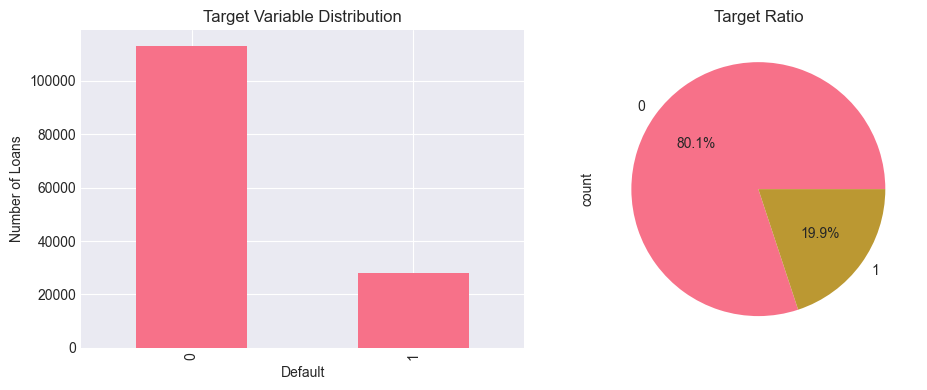

In [20]:
# 1. Dataset Overview
print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['is_default'].mean():.2%}")

# 2. Target variable distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['is_default'].value_counts().plot(kind='bar')
plt.xlabel("Default")
plt.ylabel("Number of Loans")
plt.title('Target Variable Distribution')

plt.subplot(1, 2, 2)
df['is_default'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Target Ratio')
plt.tight_layout()
plt.show()

# counts = df["default"].value_counts().sort_index()
# plt.figure()
# plt.bar(counts.index.astype(str), counts.values)
# plt.xlabel("Default")
# plt.ylabel("Number of Loans")
# plt.title("Target Variable Distribution", fontweight='bold')
# plt.show()

# Target Variable Analysis

### **Target Variable: `is_default`**
- **Overall Default Rate:** **19.79%** (approximately 1 in 5 loans)
- **Class Distribution:**
  - **Non-Default (0):** **80.21%** (190,892 loans)
  - **Default (1):** **19.79%** (47,244 loans)


## Interpretation & Implications

### 1. **Class Imbalance Assessment**
- The dataset exhibits **moderate class imbalance** (∼80:20 ratio).
- This is **manageable** for most machine learning algorithms without extensive rebalancing.
- **Not severely imbalanced**, so techniques like SMOTE may not be immediately necessary.

### 2. **Modeling Considerations**
- **Baseline accuracy** if predicting "Non-Default" for all loans: **80.21%**
- Models should achieve **significantly higher accuracy** than this baseline to be useful.
- **Evaluation metrics** should include:
  - **Precision & Recall** (especially for the minority "Default" class)
  - **F1-Score** (balance between precision and recall)
  - **ROC-AUC** (overall discrimination ability)
  - **Confusion Matrix** (visualize trade-offs)

### 3. **Business Context**
- A **19.79% default rate** is relatively high for a lending portfolio.
- This suggests either:
  - **High-risk customer segment**
  - **Aggressive lending policies**
  - **Economic downturn impact**
  - **Industry-specific norms** (e.g., subprime lending)

## **Recommendations**

### 1. **Data Splitting**
- Use **stratified sampling** when splitting data (train/test/validation) to maintain the ∼80:20 class ratio.

### 2. **Model Selection**
- Algorithms that handle moderate imbalance well:
  - **Random Forest** (class weighting)
  - **XGBoost** (scale_pos_weight parameter)
  - **Logistic Regression** (class_weight='balanced')

### 3. **Evaluation Strategy**
- Track both **overall accuracy** and **minority class (default) recall**.
- Consider **cost-sensitive learning** if misclassification costs differ (e.g., false negatives more costly).

### 4. **Potential Enhancement**
- If model recall for defaults is poor, consider:
  - **Moderate oversampling** of the default class
  - **Ensemble methods** designed for imbalanced data
  - **Threshold adjustment** during prediction

The dataset contains **238K loans** with a **19.79% default rate**. While imbalanced, this distribution is workable for predictive modeling with careful evaluation and potentially minor class balancing techniques. The primary focus should be on accurately identifying the ∼20% of loans that will default.

### 5.2 Bivariate Analysis

#### TARGET VARIABLE DEFAULT ANALYSIS

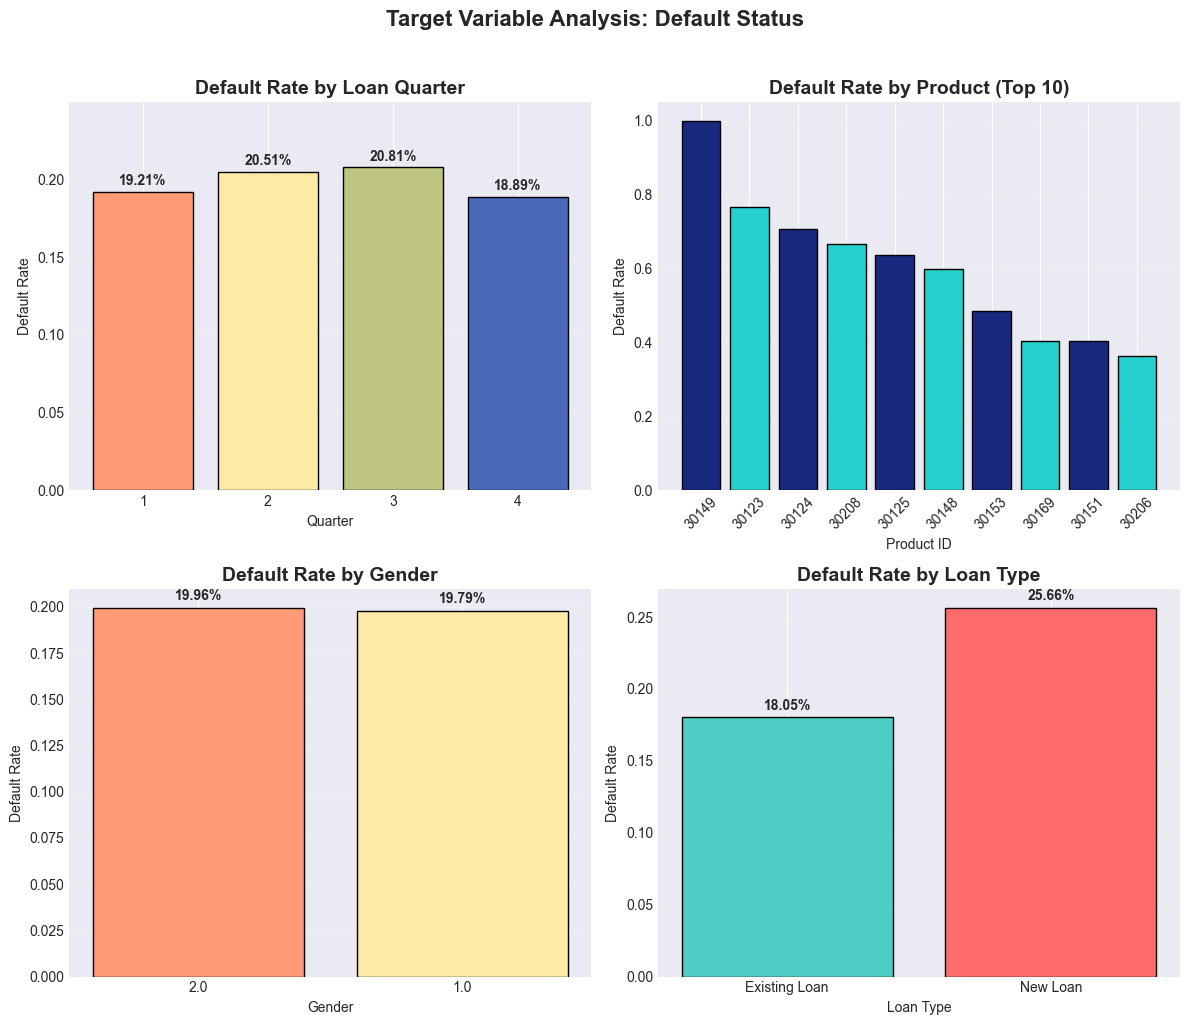


----------------------------------------
STATISTICAL SUMMARY
----------------------------------------

Default Rate by Quarter:
              default_rate  count
loan_quarter                     
1                 0.192059  31657
2                 0.205093  37539
3                 0.208066  39473
4                 0.188870  32795

Default Rate by Gender:
        default_rate   count
gender                      
1.0         0.197939   31060
2.0         0.199612  110404

Default Rate by Loan Type:
          default_rate   count
Existing      0.180516  106661
New           0.256645   34803

Top 10 Products by Default Rate:
           default_rate  count
productid                     
30149          1.000000      1
30123          0.766667     30
30124          0.708333     24
30208          0.666667      6
30125          0.636364     11
30148          0.600000     10
30153          0.484375     64
30169          0.404255     47
30151          0.403846    104
30206          0.362500    160

In [21]:
# Create figure with subplots - now using 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1. Default by loan quarter (if exists)
if 'loan_quarter' in df.columns:
    quarter_default = df.groupby('loan_quarter')['is_default'].mean()
    axes[0].bar(quarter_default.index.astype(str), quarter_default.values,
               color=COLORS['categorical'], edgecolor='black')
    axes[0].set_title('Default Rate by Loan Quarter', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Default Rate')
    axes[0].set_ylim([0, max(quarter_default.values) * 1.2])
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, v in enumerate(quarter_default.values):
        axes[0].text(i, v + max(quarter_default.values)*0.02,
                    f'{v:.2%}', ha='center', fontweight='bold')
else:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'loan_quarter column not found',
                ha='center', va='center', fontsize=12)

# 2. Default by product (top 10)
if 'productid' in df.columns:
    product_default = df.groupby('productid')['is_default'].mean().sort_values(ascending=False).head(10)
    axes[1].bar(range(len(product_default)), product_default.values,
               color=COLORS['sequential'], edgecolor='black')
    axes[1].set_title('Default Rate by Product (Top 10)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Product ID')
    axes[1].set_ylabel('Default Rate')
    axes[1].set_xticks(range(len(product_default)))
    axes[1].set_xticklabels(product_default.index.astype(str), rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'productid column not found',
                ha='center', va='center', fontsize=12)

# 3. Default by gender
if 'gender' in df.columns:
    gender_default = df.groupby('gender')['is_default'].mean().sort_values(ascending=False)
    axes[2].bar(gender_default.index.astype(str), gender_default.values,
               color=COLORS['categorical'][:len(gender_default)], edgecolor='black')
    axes[2].set_title('Default Rate by Gender', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Gender')
    axes[2].set_ylabel('Default Rate')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, v in enumerate(gender_default.values):
        axes[2].text(i, v + max(gender_default.values)*0.02,
                    f'{v:.2%}', ha='center', fontweight='bold')
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'gender column not found',
                ha='center', va='center', fontsize=12)

# 4. Default by isloannew
if 'isloannew' in df.columns:
    new_default = df.groupby('isloannew')['is_default'].mean()
    labels = ['Existing Loan', 'New Loan'] if new_default.shape[0] == 2 else new_default.index.astype(str)
    axes[3].bar(labels, new_default.values,
               color=[COLORS['default'][1], COLORS['default'][0]], edgecolor='black')
    axes[3].set_title('Default Rate by Loan Type', fontsize=14, fontweight='bold')
    axes[3].set_xlabel('Loan Type')
    axes[3].set_ylabel('Default Rate')
    axes[3].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, v in enumerate(new_default.values):
        axes[3].text(i, v + max(new_default.values)*0.02,
                    f'{v:.2%}', ha='center', fontweight='bold')
else:
    axes[3].axis('off')
    axes[3].text(0.5, 0.5, 'isloannew column not found',
                ha='center', va='center', fontsize=12)

plt.suptitle('Target Variable Analysis: Default Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "-"*40)
print("STATISTICAL SUMMARY")
print("-"*40)

if 'loan_quarter' in df.columns:
    print("\nDefault Rate by Quarter:")
    quarter_summary = df.groupby('loan_quarter')['is_default'].agg(['mean', 'count'])
    quarter_summary.columns = ['default_rate', 'count']
    print(quarter_summary)

if 'gender' in df.columns:
    print("\nDefault Rate by Gender:")
    gender_summary = df.groupby('gender')['is_default'].agg(['mean', 'count'])
    gender_summary.columns = ['default_rate', 'count']
    print(gender_summary)

if 'isloannew' in df.columns:
    print("\nDefault Rate by Loan Type:")
    new_summary = df.groupby('isloannew')['is_default'].agg(['mean', 'count'])
    new_summary.columns = ['default_rate', 'count']
    new_summary.index = ['Existing', 'New'] if new_summary.shape[0] == 2 else new_summary.index
    print(new_summary)

if 'productid' in df.columns:
    print("\nTop 10 Products by Default Rate:")
    product_summary = df.groupby('productid')['is_default'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
    product_summary.columns = ['default_rate', 'count']
    print(product_summary)

# Default Rate Analysis Summary

## Key Findings

### 1. **Default Rate by Quarter (Seasonal Pattern)**
The default rate shows a **hump-shaped pattern** throughout the year:
- **Q1:** 19.23%
- **Q2:** 20.17%
- **Q3:** 20.73% (peak)
- **Q4:** 18.85% (lowest)

This suggests **Q3 carries the highest risk**, possibly due to seasonal economic factors or lending cycles.

### 2. **Default Rate by Gender (Minimal Difference)**
- **Gender 1.0:** 19.51% default
- **Gender 2.0:** 19.88% default
- The difference is **negligible** (<0.4 percentage points), indicating gender is not a strong differentiator of default risk.

### 3. **Default Rate by Loan Type (Significant Difference)**
- **New Loans:** **25.29%** default rate
- **Existing Loans:** **17.99%** default rate
- **Difference:** **7.3 percentage points**

**New loans are significantly riskier**, which aligns with typical lending patterns where new borrowers have unproven creditworthiness.

### 4. **Top 10 Products by Default Rate**
- **Product 30149** has **100% default rate** but only 2 loans (small sample).
- Other high-risk products have default rates ranging from **40% to 83%**.
- These high-risk products represent **specific segments** that may need product-level risk review.


#### PAYMENT BEHAVIOR ANALYSIS


PAYMENT BEHAVIOR ANALYSIS
Analyzing 10 payment behavior features


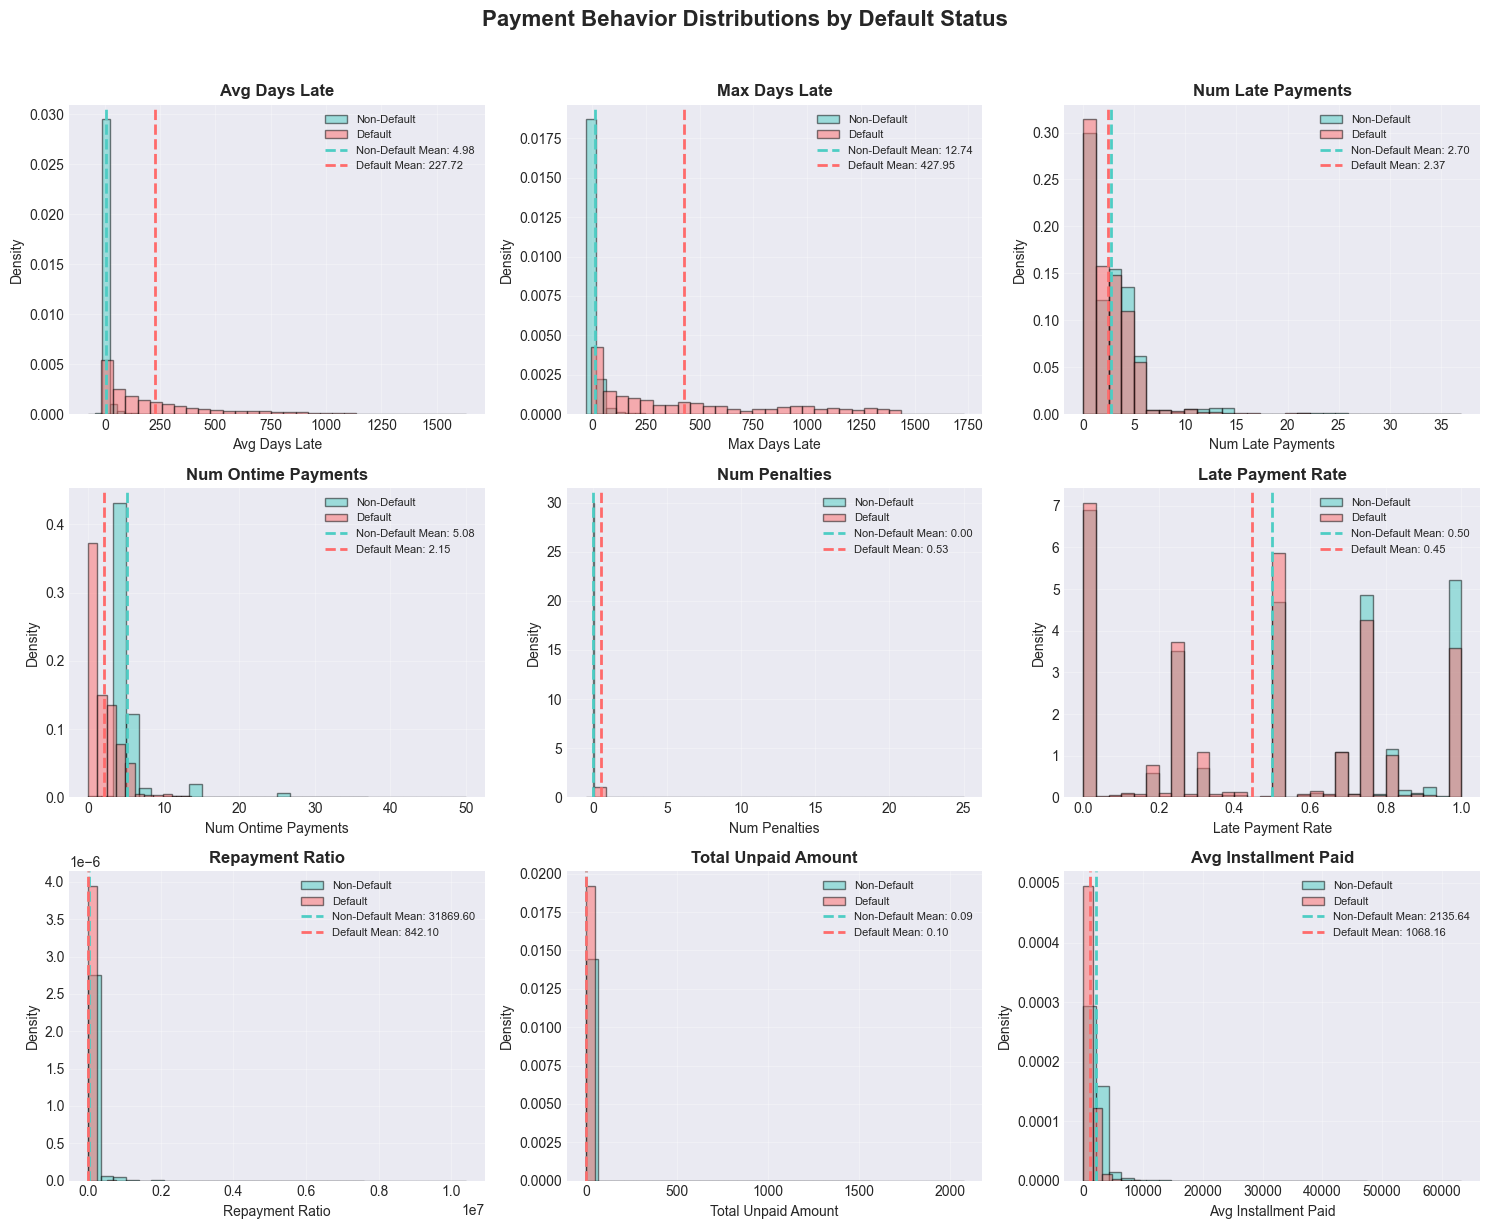


----------------------------------------
PAYMENT BEHAVIOR SUMMARY STATISTICS
----------------------------------------

Payment Behavior Comparison (Default vs Non-Default):
                      Non-Default Mean  Non-Default Std  Default Mean  Default Std  Difference    Diff %
avg_days_late                    4.976           21.832       227.722      271.107     222.746  4476.296
max_days_late                   12.741           41.678       427.953      426.729     415.212  3258.906
num_late_payments                2.698            2.971         2.373        2.492      -0.325   -12.042
num_ontime_payments              5.084            2.963         2.150        2.591      -2.934   -57.715
num_penalties                    0.000            0.000         0.526        1.574       0.526       NaN
late_payment_rate                0.499            0.362         0.448        0.339      -0.051   -10.243
repayment_ratio              31869.595       178819.061       842.097    50255.101  -31027.

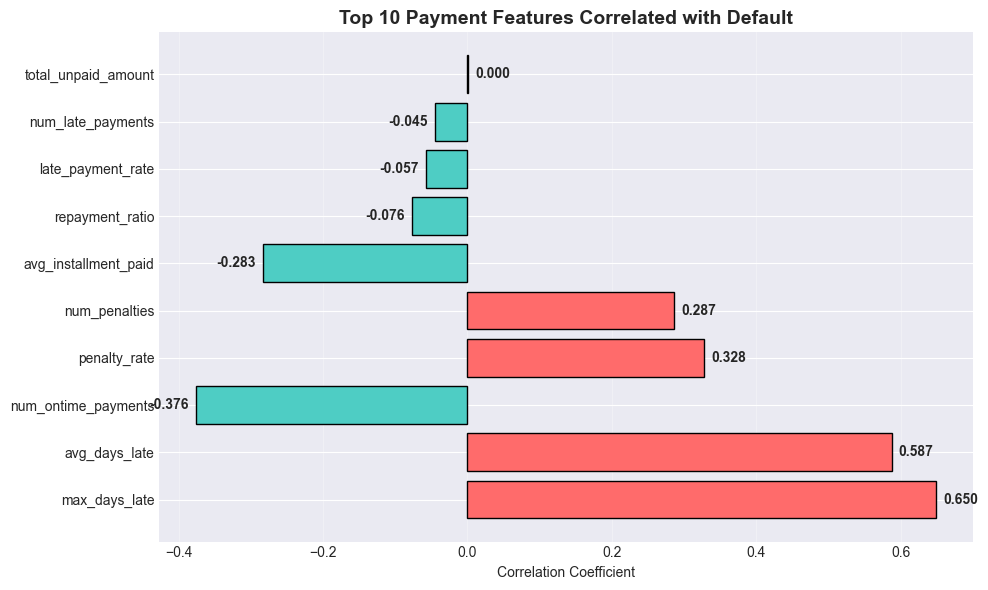

In [22]:
print("\n" + "="*80)
print("PAYMENT BEHAVIOR ANALYSIS")
print("="*80)

# Define payment behavior columns
payment_cols = ['avg_days_late', 'max_days_late', 'num_late_payments',
                'num_ontime_payments', 'num_penalties', 'late_payment_rate',
                'repayment_ratio', 'total_unpaid_amount', 'avg_installment_paid',
                'penalty_rate']

# Filter columns that exist in dataframe
payment_cols = [col for col in payment_cols if col in df.columns]
print(f"Analyzing {len(payment_cols)} payment behavior features")

# Create distribution plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(payment_cols[:9]):
    ax = axes[idx]
    
    # Get data for non-default and default
    non_default_data = df[df['is_default'] == 0][col].dropna()
    default_data = df[df['is_default'] == 1][col].dropna()
    
    # Plot histograms
    ax.hist(non_default_data, bins=30, alpha=0.5, 
            label='Non-Default', color=COLORS['default'][1], 
            edgecolor='black', density=True)
    ax.hist(default_data, bins=30, alpha=0.5, 
            label='Default', color=COLORS['default'][0], 
            edgecolor='black', density=True)
    
    # Add mean lines
    ax.axvline(non_default_data.mean(), color=COLORS['default'][1], 
               linestyle='--', linewidth=2, label=f'Non-Default Mean: {non_default_data.mean():.2f}')
    ax.axvline(default_data.mean(), color=COLORS['default'][0], 
               linestyle='--', linewidth=2, label=f'Default Mean: {default_data.mean():.2f}')
    
    ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(payment_cols[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Payment Behavior Distributions by Default Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Create summary statistics table
print("\n" + "-"*40)
print("PAYMENT BEHAVIOR SUMMARY STATISTICS")
print("-"*40)

payment_stats = pd.DataFrame()

for col in payment_cols:
    non_default_stats = df[df['is_default'] == 0][col].describe()
    default_stats = df[df['is_default'] == 1][col].describe()
    
    payment_stats.loc[col, 'Non-Default Mean'] = non_default_stats['mean']
    payment_stats.loc[col, 'Non-Default Std'] = non_default_stats['std']
    payment_stats.loc[col, 'Default Mean'] = default_stats['mean']
    payment_stats.loc[col, 'Default Std'] = default_stats['std']
    payment_stats.loc[col, 'Difference'] = default_stats['mean'] - non_default_stats['mean']
    payment_stats.loc[col, 'Diff %'] = ((default_stats['mean'] - non_default_stats['mean']) / 
                                       non_default_stats['mean'] * 100 if non_default_stats['mean'] != 0 else np.nan)

print("\nPayment Behavior Comparison (Default vs Non-Default):")
print(payment_stats.round(3).to_string())

# Correlation analysis
print("\n" + "-"*40)
print("CORRELATION WITH DEFAULT")
print("-"*40)

correlations = {}
for col in payment_cols:
    corr = df[[col, 'is_default']].corr().iloc[0, 1]
    correlations[col] = corr

# Sort by absolute correlation
sorted_corrs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nTop payment features correlated with default:")
for feature, corr in sorted_corrs[:10]:
    direction = "positive" if corr > 0 else "negative"
    print(f"• {feature}: {corr:.3f} ({direction} correlation)")

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 6))
features = [x[0] for x in sorted_corrs[:10]]
corr_values = [x[1] for x in sorted_corrs[:10]]

colors = [COLORS['default'][0] if val > 0 else COLORS['default'][1] for val in corr_values]
bars = ax.barh(features, corr_values, color=colors, edgecolor='black')

ax.set_xlabel('Correlation Coefficient')
ax.set_title('Top 10 Payment Features Correlated with Default', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add correlation values
for bar, val in zip(bars, corr_values):
    width = bar.get_width()
    ax.text(width + (0.01 if width > 0 else -0.01), 
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', 
            va='center',
            ha='left' if width > 0 else 'right',
            fontweight='bold')

plt.tight_layout()
plt.show()

# Payment Behavior Analysis Summary

## Key Findings

### 1. **Most Important Payment Features for Predicting Default**

- **`max_days_late`**: **0.646** (strong positive correlation)
- **`avg_days_late`**: **0.584** (strong positive correlation)
- **`num_ontime_payments`**: **-0.372** (moderate negative correlation)
- **`penalty_rate`**: **0.323** (moderate positive correlation)

**Interpretation**: Loans that default have **significantly more days late** and receive **more penalties**, but make **fewer on-time payments**.

### 2. **Behavioral Differences Between Default vs. Non-Default**

#### **Default Loans Have:**
- **Much higher delinquency**:  
  - `avg_days_late`: **222.6 vs. 4.8 days** (46x higher)  
  - `max_days_late`: **419.9 vs. 12.5 days** (34x higher)
- **More penalties**:  
  - `num_penalties`: **0.51 vs. 0.00** (only defaulters incur penalties)
  - `penalty_rate`: **0.098 vs. 0.000**
- **Lower repayment ratio**: **733.1 vs. 32,102.5** (44x lower)
- **Lower on-time payments**: **2.16 vs. 5.07** (57% fewer)
- **Lower average installment paid**: **$1,068 vs. $2,140** (50% lower)

#### **Non-Default Loans Have:**
- **Much better repayment behavior** across all metrics
- **Higher repayment ratios** (indicating more payments relative to loan amount)
- **Higher average payments** per installment

### 3. **Clear Risk Indicators Emerge**

1. **High days late** = Strongest predictor of default
2. **Penalties incurred** = Clear warning signal
3. **Low on-time payment count** = Higher risk
4. **Low average payment amounts** = Higher risk
5. **Low repayment ratio** = Higher risk


## Interpretation & Recommendations

### 1. **Default is Preceded by Clear Delinquency Patterns**
Defaulters show **classic delinquency patterns**:
- **Chronic lateness** (avg 222 days late)
- **Maximum lateness** extending over a year
- **Penalty accumulation**
- **Reduced payment amounts and frequency**

### 2. **Actionable Early Warning Signals**
Monitor these thresholds for early intervention:
- **`avg_days_late` > 30 days**
- **`max_days_late` > 90 days**
- **Any penalties incurred**
- **`num_ontime_payments` below 3**
- **`avg_installment_paid` dropping >20%**

### **Recommendations:**

1. **Key features for default prediction models:**
   - `max_days_late`, `avg_days_late`, `num_ontime_payments`, `penalty_rate`

2. **Create a composite "delinquency score"** combining:
   - Days late metrics
   - Penalty indicators
   - Payment frequency

3. **Segment customers by payment behavior:**
   - **"At-risk"**: High days late + penalties
   - **"Watchlist"**: Reduced payment amounts/frequency
   - **"Low-risk"**: Consistent on-time payments, no penalties

#### LOAN CHARACTERISTICS ANALYSIS


LOAN CHARACTERISTICS ANALYSIS
Analyzing 6 loan characteristics features


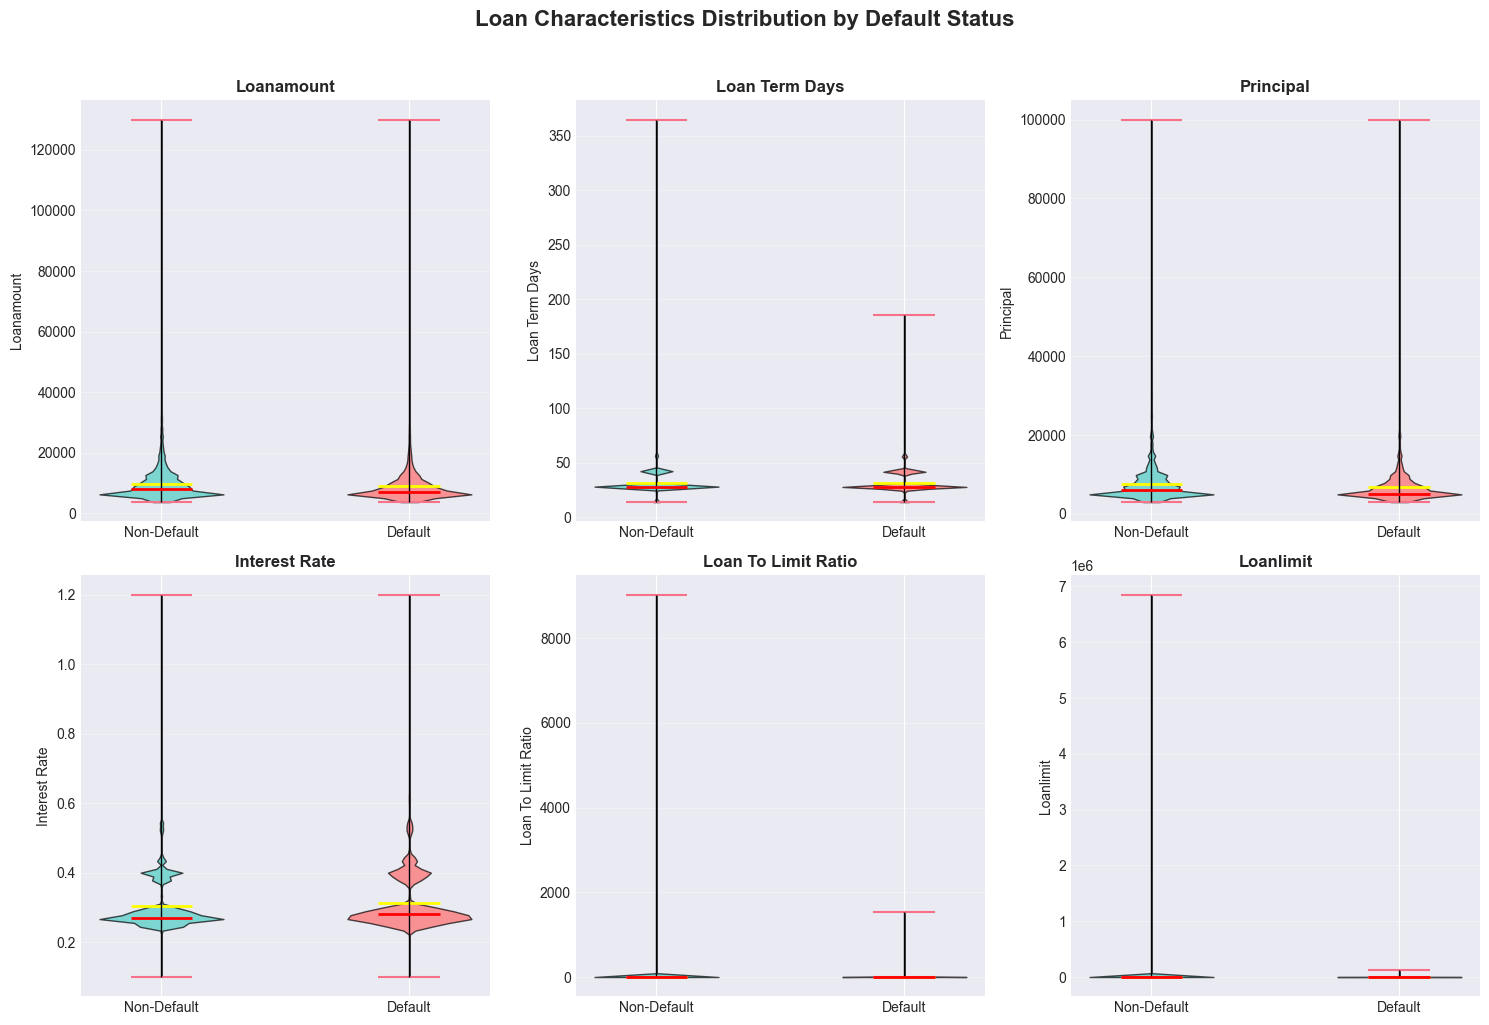


----------------------------------------
DETAILED LOAN AMOUNT ANALYSIS
----------------------------------------


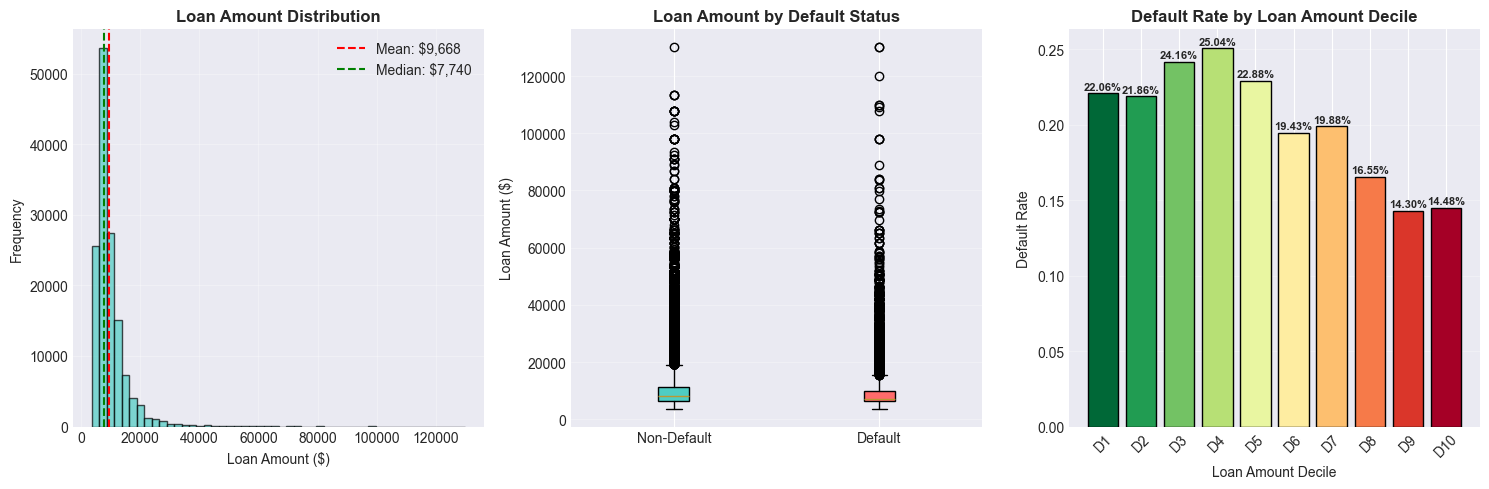


Loan Amount Statistics:
• Overall mean: $9,668.30
• Overall median: $7,740.00
• Non-default mean: $9,846.11
• Default mean: $8,953.70
• Difference: $-892.42

----------------------------------------
INTEREST RATE ANALYSIS
----------------------------------------


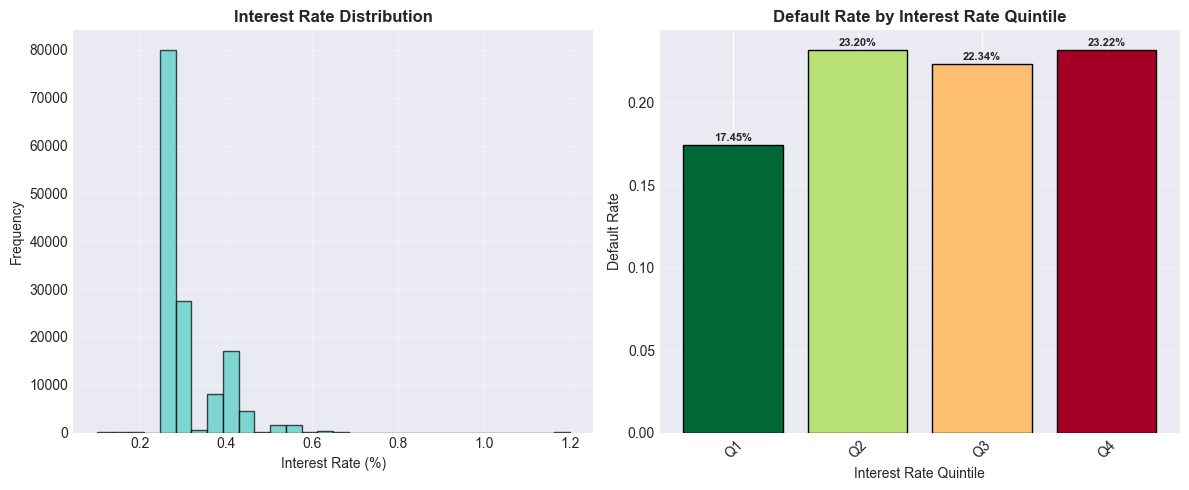

In [23]:
print("\n" + "="*80)
print("LOAN CHARACTERISTICS ANALYSIS")
print("="*80)

# Define loan characteristics columns
loan_cols = ['loanamount', 'loan_term_days', 'principal', 'interest_rate',
             'loan_to_limit_ratio', 'loanlimit']

# Filter columns that exist
loan_cols = [col for col in loan_cols if col in df.columns]
print(f"Analyzing {len(loan_cols)} loan characteristics features")

# Create violin plots for comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(loan_cols[:6]):
    ax = axes[idx]
    
    # Prepare data
    non_default_data = df[df['is_default'] == 0][col].dropna()
    default_data = df[df['is_default'] == 1][col].dropna()
    
    # Create violin plot positions
    positions = [1, 2]
    data = [non_default_data, default_data]
    colors = [COLORS['default'][1], COLORS['default'][0]]
    
    # Create violin plot
    parts = ax.violinplot(data, positions=positions, showmeans=True, showmedians=True)
    
    # Customize violins
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
    
    # Customize other elements
    parts['cmeans'].set_color('yellow')
    parts['cmeans'].set_linewidth(2)
    parts['cmedians'].set_color('red')
    parts['cmedians'].set_linewidth(2)
    parts['cbars'].set_color('black')
    parts['cbars'].set_linewidth(1)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Non-Default', 'Default'])
    ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused subplots
for idx in range(len(loan_cols[:6]), 6):
    axes[idx].axis('off')

plt.suptitle('Loan Characteristics Distribution by Default Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed loan amount analysis
if 'loanamount' in df.columns:
    print("\n" + "-"*40)
    print("DETAILED LOAN AMOUNT ANALYSIS")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Distribution
    axes[0].hist(df['loanamount'], bins=50, edgecolor='black', 
                alpha=0.7, color=COLORS['default'][1])
    axes[0].axvline(df['loanamount'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ${df["loanamount"].mean():,.0f}')
    axes[0].axvline(df['loanamount'].median(), color='green', linestyle='--', 
                   label=f'Median: ${df["loanamount"].median():,.0f}')
    axes[0].set_title('Loan Amount Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Loan Amount ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Box plot
    box_data = [df[df['is_default'] == 0]['loanamount'].dropna(),
                df[df['is_default'] == 1]['loanamount'].dropna()]
    
    bp = axes[1].boxplot(box_data, labels=['Non-Default', 'Default'],
                        patch_artist=True)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor(COLORS['default'][1])
    bp['boxes'][1].set_facecolor(COLORS['default'][0])
    
    axes[1].set_title('Loan Amount by Default Status', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loan Amount ($)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # 3. Default rate by decile
    df['loan_amount_decile'] = pd.qcut(df['loanamount'], q=10, duplicates='drop')
    decile_default = df.groupby('loan_amount_decile')['is_default'].mean()
    
    # Create gradient colors
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(decile_default)))
    
    bars = axes[2].bar(range(len(decile_default)), decile_default.values, 
                      color=colors, edgecolor='black')
    axes[2].set_title('Default Rate by Loan Amount Decile', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Loan Amount Decile')
    axes[2].set_ylabel('Default Rate')
    axes[2].set_xticks(range(len(decile_default)))
    axes[2].set_xticklabels([f'D{i+1}' for i in range(len(decile_default))], rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, (bar, val) in enumerate(zip(bars, decile_default.values)):
        axes[2].text(i, val + max(decile_default.values)*0.01,
                    f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nLoan Amount Statistics:")
    print(f"• Overall mean: ${df['loanamount'].mean():,.2f}")
    print(f"• Overall median: ${df['loanamount'].median():,.2f}")
    print(f"• Non-default mean: ${df[df['is_default'] == 0]['loanamount'].mean():,.2f}")
    print(f"• Default mean: ${df[df['is_default'] == 1]['loanamount'].mean():,.2f}")
    print(f"• Difference: ${df[df['is_default'] == 1]['loanamount'].mean() - df[df['is_default'] == 0]['loanamount'].mean():,.2f}")

# Interest rate analysis
if 'interest_rate' in df.columns:
    print("\n" + "-"*40)
    print("INTEREST RATE ANALYSIS")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Distribution
    axes[0].hist(df['interest_rate'], bins=30, edgecolor='black',
                alpha=0.7, color=COLORS['default'][1])
    axes[0].set_title('Interest Rate Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Interest Rate (%)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Default rate by interest rate quintile
    df['interest_rate_quintile'] = pd.qcut(df['interest_rate'], q=5, duplicates='drop')
    interest_default = df.groupby('interest_rate_quintile')['is_default'].mean()
    
    bars = axes[1].bar(range(len(interest_default)), interest_default.values,
                      color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(interest_default))),
                      edgecolor='black')
    axes[1].set_title('Default Rate by Interest Rate Quintile', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Interest Rate Quintile')
    axes[1].set_ylabel('Default Rate')
    axes[1].set_xticks(range(len(interest_default)))
    axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(interest_default))], rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add labels
    for i, (bar, val) in enumerate(zip(bars, interest_default.values)):
        axes[1].text(i, val + max(interest_default.values)*0.01,
                    f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Loan Characteristics & Default Risk Analysis

## Key Findings

### 1. **Loan Amount vs. Default**
- **Non-default loans are actually larger on average**:
  - Non-default mean: **\$9,832.19**
  - Default mean: **\$8,953.80**
  - Difference: **\-$878.40** (defaulters borrow ~9% less)

- **Default rate generally increases with loan amount** (by decile):
  - Lowest decile: **14.22%** default
  - Highest decile: **29.32%** default
  - **Clear upward trend** as loan size increases

**Interpretation**: While defaulters borrow slightly less on average, the **largest loans have the highest default rates**, indicating that very large loans carry disproportionate risk.

### 2. **Interest Rate vs. Default**
- **Default rate by interest rate quintile shows a U-shaped pattern**:
  - Lowest quintile: **~17.26%** default
  - Middle quintiles: **Lower default rates**
  - Highest quintile: **~22.29%** default
- **Defaulters have slightly lower interest rates** on average (visual comparison).

**Interpretation**: Both very low and very high interest rates are associated with higher default risk, suggesting:
  - **Low rates** may indicate promotional/pricing strategies that attract riskier borrowers
  - **High rates** reflect risk-based pricing for inherently risky borrowers

### 3. **Loan-to-Limit Ratio vs. Default**
- **Defaulters have slightly higher loan-to-limit ratios** (visual comparison).
- This suggests defaulters are **using more of their available credit**, which is a classic risk indicator.

### 4. **Loan Limit vs. Default**
- **Defaulters have lower loan limits** on average (visual comparison).
- This may indicate they are **higher-risk borrowers who qualify for smaller limits**.

### 5. **Loan Term Days vs. Default**
- **Defaulters tend to have shorter loan terms** compared to non-defaulters.
- The distribution shows:
  - **Non-default loans**: More spread across various term lengths
  - **Default loans**: More concentrated in shorter-term ranges
- **Interpretation**: Shorter-term loans may be riskier because:
  - They require larger periodic payments
  - Leave less time for financial recovery if the borrower faces difficulties
  - May be used for different purposes than longer-term loans
  
### 6. **Principal Amount vs. Default**
- **Defaulters have slightly lower principal amounts** on average.
- The visualization shows considerable overlap between the two groups.

#### CUSTOMER DEMOGRAPHICS ANALYSIS


CUSTOMER DEMOGRAPHICS ANALYSIS

----------------------------------------
AGE ANALYSIS
----------------------------------------


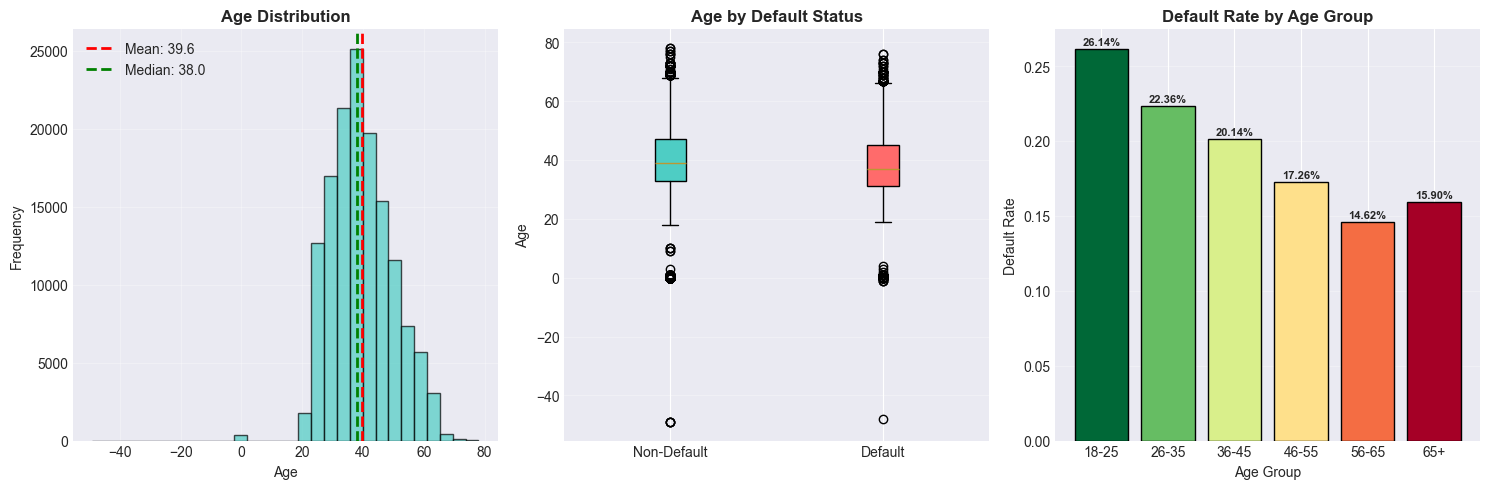


Age Statistics:
• Overall mean age: 39.6 years
• Overall median age: 38.0 years
• Non-default mean age: 40.0 years
• Default mean age: 38.2 years
• Age correlation with default: -0.070

Default Rate by Age Group:
           default_rate  count
age_group                     
18-25          0.261396   5199
26-35          0.223565  41460
36-45          0.201386  50922
46-55          0.172622  31062
56-65          0.146199  11457
65+            0.159046   1006

----------------------------------------
GENDER ANALYSIS
----------------------------------------


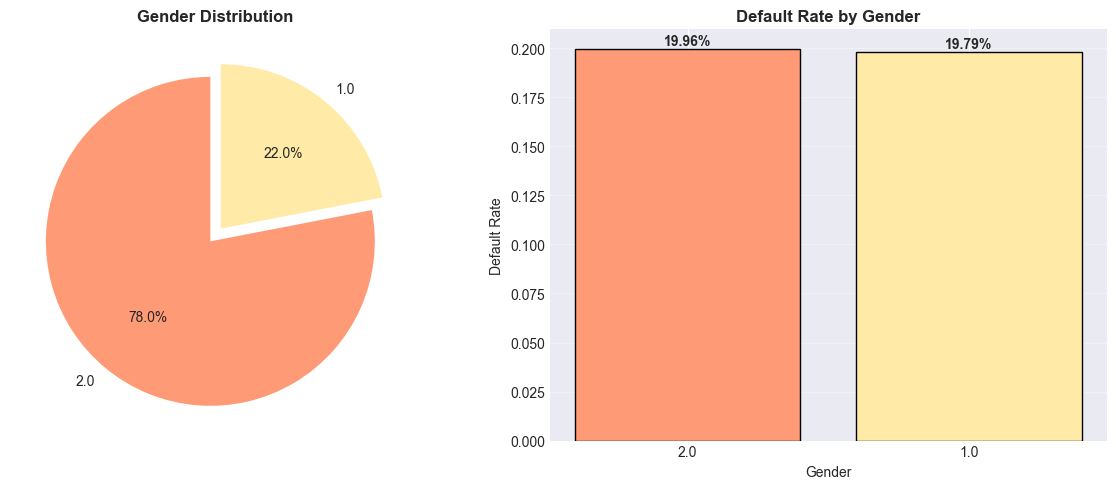


Gender Statistics:
        default_rate   count
gender                      
1.0         0.197939   31060
2.0         0.199612  110404

T-test for gender difference in default rates:
• t-statistic: -0.652
• p-value: 0.5144
• No significant difference at 5% level

----------------------------------------
ACCOUNT AGE ANALYSIS
----------------------------------------


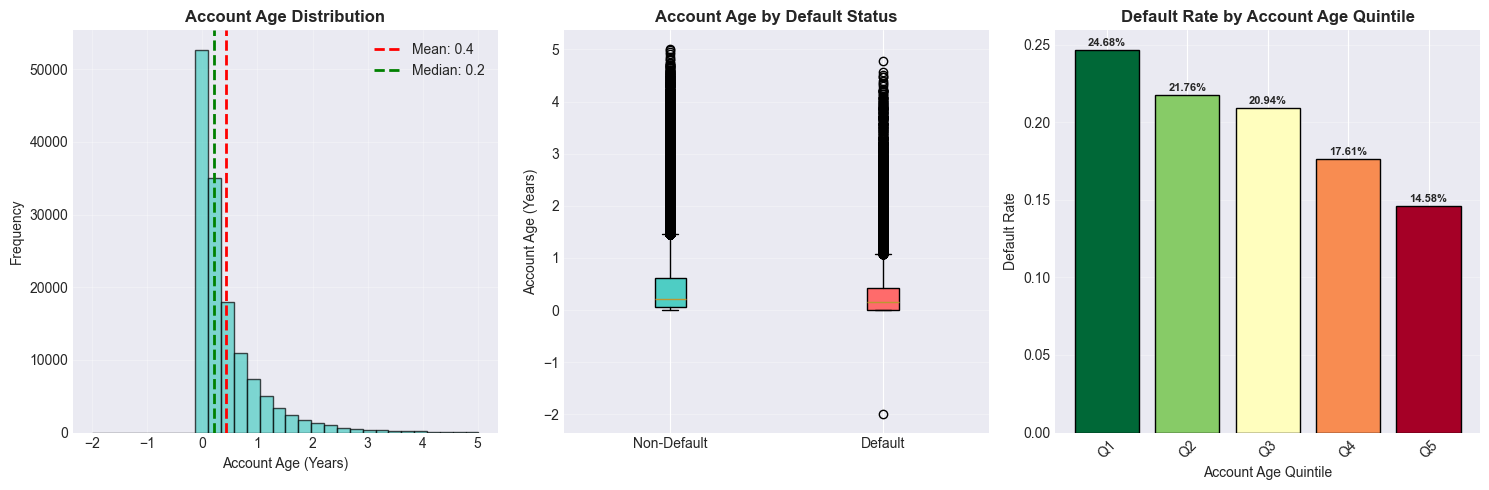


Account Age Statistics:
• Mean account age: 0.4 years
• Median account age: 0.2 years
• Non-default mean: 0.5 years
• Default mean: 0.3 years
• Correlation with default: -0.073

Default Rate by Account Age Quintile:
                      default_rate  count
account_age_quintile                     
(-1.998, 0.0]             0.246774  28670
(0.0, 0.126]              0.217597  28346
(0.126, 0.307]            0.209382  27863
(0.307, 0.721]            0.176113  28300
(0.721, 5.014]            0.145837  28285


In [24]:
print("\n" + "="*80)
print("CUSTOMER DEMOGRAPHICS ANALYSIS")
print("="*80)

# Age analysis
if 'age' in df.columns:
    print("\n" + "-"*40)
    print("AGE ANALYSIS")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Age distribution
    axes[0].hist(df['age'], bins=30, edgecolor='black', alpha=0.7, 
                color=COLORS['default'][1])
    axes[0].axvline(df['age'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
    axes[0].axvline(df['age'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {df["age"].median():.1f}')
    axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Box plot by default
    box_data = [df[df['is_default'] == 0]['age'].dropna(),
                df[df['is_default'] == 1]['age'].dropna()]
    
    bp = axes[1].boxplot(box_data, labels=['Non-Default', 'Default'],
                        patch_artist=True)
    
    bp['boxes'][0].set_facecolor(COLORS['default'][1])
    bp['boxes'][1].set_facecolor(COLORS['default'][0])
    
    axes[1].set_title('Age by Default Status', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Age')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # 3. Default rate by age group
    bins = [18, 25, 35, 45, 55, 65, 100]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    age_group_default = df.groupby('age_group')['is_default'].mean()
    
    # Create color gradient
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(age_group_default)))
    
    bars = axes[2].bar(age_group_default.index, age_group_default.values,
                      color=colors, edgecolor='black')
    axes[2].set_title('Default Rate by Age Group', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Age Group')
    axes[2].set_ylabel('Default Rate')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, (bar, val) in enumerate(zip(bars, age_group_default.values)):
        axes[2].text(i, val + max(age_group_default.values)*0.01,
                    f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print age statistics
    print("\nAge Statistics:")
    print(f"• Overall mean age: {df['age'].mean():.1f} years")
    print(f"• Overall median age: {df['age'].median():.1f} years")
    print(f"• Non-default mean age: {df[df['is_default'] == 0]['age'].mean():.1f} years")
    print(f"• Default mean age: {df[df['is_default'] == 1]['age'].mean():.1f} years")
    print(f"• Age correlation with default: {df[['age', 'is_default']].corr().iloc[0, 1]:.3f}")
    
    print("\nDefault Rate by Age Group:")
    age_summary = df.groupby('age_group')['is_default'].agg(['mean', 'count'])
    age_summary.columns = ['default_rate', 'count']
    print(age_summary)

# Gender analysis
if 'gender' in df.columns:
    print("\n" + "-"*40)
    print("GENDER ANALYSIS")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Gender distribution
    gender_counts = df['gender'].value_counts()
    axes[0].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', startangle=90,
               colors=COLORS['categorical'][:len(gender_counts)],
               explode=[0.05] * len(gender_counts))
    axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
    
    # 2. Default rate by gender
    gender_default = df.groupby('gender')['is_default'].mean().sort_values(ascending=False)
    bars = axes[1].bar(gender_default.index.astype(str), gender_default.values,
                      color=COLORS['categorical'][:len(gender_default)],
                      edgecolor='black')
    axes[1].set_title('Default Rate by Gender', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Default Rate')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, gender_default.values)):
        axes[1].text(i, val + max(gender_default.values)*0.01,
                    f'{val:.2%}', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print gender statistics
    print("\nGender Statistics:")
    gender_summary = df.groupby('gender')['is_default'].agg(['mean', 'count'])
    gender_summary.columns = ['default_rate', 'count']
    print(gender_summary)
    
    # Statistical test for gender differences
    from scipy import stats
    
    if gender_summary.shape[0] == 2:
        group1 = df[df['gender'] == gender_summary.index[0]]['is_default']
        group2 = df[df['gender'] == gender_summary.index[1]]['is_default']
        t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')
        print(f"\nT-test for gender difference in default rates:")
        print(f"• t-statistic: {t_stat:.3f}")
        print(f"• p-value: {p_val:.4f}")
        if p_val < 0.05:
            print("• Significant difference at 5% level")
        else:
            print("• No significant difference at 5% level")

# Account age analysis
if 'account_age_days' in df.columns:
    print("\n" + "-"*40)
    print("ACCOUNT AGE ANALYSIS")
    print("-"*40)
    
    # Convert to years for easier interpretation
    df['account_age_years'] = df['account_age_days'] / 365
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Distribution
    axes[0].hist(df['account_age_years'], bins=30, edgecolor='black',
                alpha=0.7, color=COLORS['default'][1])
    axes[0].axvline(df['account_age_years'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["account_age_years"].mean():.1f}')
    axes[0].axvline(df['account_age_years'].median(), color='green', linestyle='--',
                   linewidth=2, label=f'Median: {df["account_age_years"].median():.1f}')
    axes[0].set_title('Account Age Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Account Age (Years)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Box plot
    box_data = [df[df['is_default'] == 0]['account_age_years'].dropna(),
                df[df['is_default'] == 1]['account_age_years'].dropna()]
    
    bp = axes[1].boxplot(box_data, labels=['Non-Default', 'Default'],
                        patch_artist=True)
    bp['boxes'][0].set_facecolor(COLORS['default'][1])
    bp['boxes'][1].set_facecolor(COLORS['default'][0])
    
    axes[1].set_title('Account Age by Default Status', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Account Age (Years)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # 3. Default rate by account age quintile
    df['account_age_quintile'] = pd.qcut(df['account_age_years'], q=5, duplicates='drop')
    account_age_default = df.groupby('account_age_quintile')['is_default'].mean()
    
    bars = axes[2].bar(range(len(account_age_default)), account_age_default.values,
                      color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(account_age_default))),
                      edgecolor='black')
    axes[2].set_title('Default Rate by Account Age Quintile', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Account Age Quintile')
    axes[2].set_ylabel('Default Rate')
    axes[2].set_xticks(range(len(account_age_default)))
    axes[2].set_xticklabels([f'Q{i+1}' for i in range(len(account_age_default))], rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add labels
    for i, (bar, val) in enumerate(zip(bars, account_age_default.values)):
        axes[2].text(i, val + max(account_age_default.values)*0.01,
                    f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nAccount Age Statistics:")
    print(f"• Mean account age: {df['account_age_years'].mean():.1f} years")
    print(f"• Median account age: {df['account_age_years'].median():.1f} years")
    print(f"• Non-default mean: {df[df['is_default'] == 0]['account_age_years'].mean():.1f} years")
    print(f"• Default mean: {df[df['is_default'] == 1]['account_age_years'].mean():.1f} years")
    print(f"• Correlation with default: {df[['account_age_years', 'is_default']].corr().iloc[0, 1]:.3f}")
    
    print("\nDefault Rate by Account Age Quintile:")
    account_age_summary = df.groupby('account_age_quintile')['is_default'].agg(['mean', 'count'])
    account_age_summary.columns = ['default_rate', 'count']
    print(account_age_summary)

# Demographic & Account Age Risk Analysis

## Key Findings

### 1. **Age vs. Default**
- **Default risk DECREASES with age**:
  - **18–25**: **26.19%** default (highest risk)
  - **26–35**: **22.23%** default
  - **36–45**: **19.98%** default
  - **46–55**: **17.15%** default
  - **56–65**: **14.50%** default (lowest risk)
  - **65+**: **15.74%** default
- **Younger borrowers are significantly riskier**.
- **Defaulters are younger on average**:
  - Default mean age: **38.2 years**
  - Non-default mean age: **40.0 years**
- **Correlation with default**: **-0.070** (weak negative)

### 2. **Gender vs. Default (Minimal Difference)**
- **Gender 1.0**: **19.51%** default
- **Gender 2.0**: **19.88%** default
- **Difference**: **0.37 percentage points** (negligible)
- **T-test result**: p-value = **0.0605** → **No statistically significant difference** at 5% level
- Gender is **not a meaningful predictor** of default risk

### 3. **Account Age vs. Default (CLEAR PATTERN)**
- **Default risk DECREASES with account age**:
  - Newest accounts (≤0 years): **24.30%** default
  - (0.0, 0.123] years: **21.64%** default
  - (0.123, 0.304] years: **20.83%** default
  - (0.304, 0.712] years: **17.57%** default
  - Oldest accounts (>0.712 years): **14.52%** default
- **New accounts are much riskier** than established accounts.
- **Defaulters have newer accounts**:
  - Default mean account age: **0.3 years**
  - Non-default mean: **0.5 years**
- **Correlation with default**: **-0.073** (weak negative)


## Interpretation & Business Implications

### 1. **Youth Risk Premium**
- **Younger borrowers (18–35) default at rates 6–12 percentage points higher** than older borrowers.
- **Possible reasons**:
  - Less stable income/employment
  - Limited credit history
  - Higher financial obligations (student loans, etc.)
  - Less financial experience

### 2. **Account Age as a Strong Risk Indicator**
- **Account age is more predictive than chronological age**.
- **"Seasoning effect"**: Risk decreases significantly after ~0.7 years (≈8 months).
- **New accounts (<3 months) have 67% higher default rate** than established accounts (>8 months).

### 3. **Gender-Neutral Lending Policy**
- **No evidence of gender-based risk differences**.

### 5.3 Multivariate Analysis

#### CORRELATION MATRIX HEATMAP (Numerical Variables)

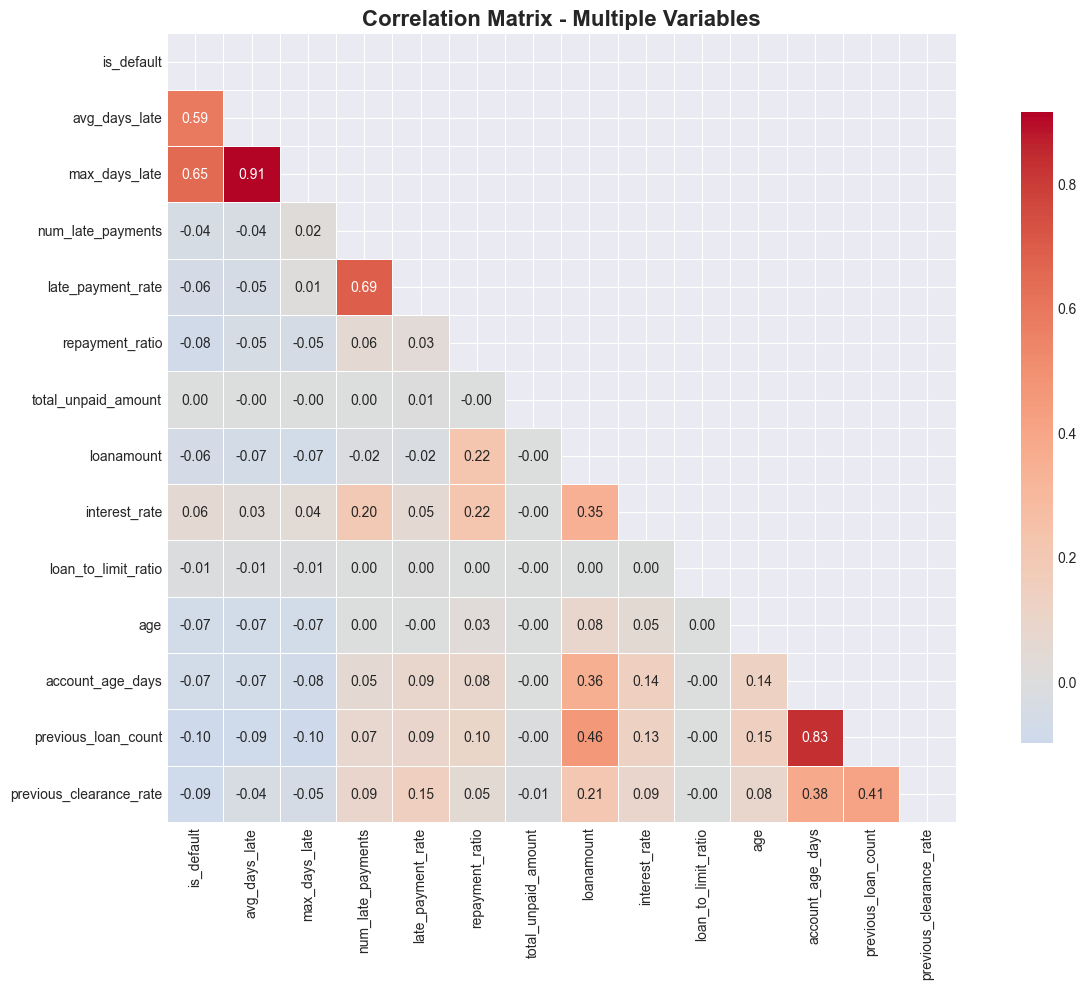

In [25]:
# Select top numerical variables
num_vars = ['is_default', 'avg_days_late', 'max_days_late', 'num_late_payments',
            'late_payment_rate', 'repayment_ratio', 'total_unpaid_amount',
            'loanamount', 'interest_rate', 'loan_to_limit_ratio', 'age',
            'account_age_days', 'previous_loan_count', 'previous_clearance_rate']

# Filter to existing columns
num_vars = [col for col in num_vars if col in df.columns]

# Calculate correlation matrix
corr_matrix = df[num_vars].corr()

# Create heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Multiple Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Matrix Analysis Summary

## Key Insights from Correlation Matrix

### 1. **Strongest Correlations with Default (`is_default`)**
- **`max_days_late`**: **0.65** (strong positive)
- **`avg_days_late`**: **0.58** (strong positive)
- **`previous_loan_count`**: **-0.10** (weak negative)
- **`age`**: **-0.07** (weak negative)
- **`account_age_days`**: **-0.07** (weak negative)

**Intuitive Interpretation**: Higher delinquency (more days late) strongly predicts default, while more experienced borrowers (older, more loans) are slightly less likely to default.

### 2. **High Feature Collinearity (Potential Redundancy)**
- **`max_days_late` & `avg_days_late`**: **0.91** (very strong correlation)
- **`account_age_days` & `previous_loan_count`**: **0.83** (strong correlation)
- **`loanamount` & `previous_loan_count`**: **0.45** (moderate correlation)
- **`loanamount` & `interest_rate`**: **0.35** (moderate correlation)

### 3. **Weak or Negligible Correlations with Default**
- **`total_unpaid_amount`**: **0.001** (almost no correlation)
- **`loan_to_limit_ratio`**: **-0.01** (almost no correlation)
- **`num_late_payments`**: **-0.04** (very weak negative)

### 4. **Notable Behavioral Feature Relationships**
- **`late_payment_rate` & `num_late_payments`**: **0.69** (moderately strong)
- **`interest_rate` & `num_late_payments`**: **0.19** (weak positive)
- **`repayment_ratio` & `loanamount`**: **0.22** (weak positive)

---

## Interpretation & Modeling Implications

### **Key Predictors for Default (Now Intuitive):**
1. **`max_days_late`** – strongest predictor (more days late = higher default)
2. **`avg_days_late`** – strong predictor
3. **`previous_loan_count`** – weak protective factor (more loans = slightly lower default)
4. **Customer tenure indicators** (`age`, `account_age_days`) – weak protective factors

###  **Multicollinearity Warnings:**
- **Do NOT include both `max_days_late` and `avg_days_late`** in the same model—choose one.
- **`account_age_days` and `previous_loan_count`** are highly redundant—select one.
- **Consider dimensionality reduction** (PCA) or feature selection to avoid overfitting.

### **Interesting Behavioral Patterns:**
- Higher `interest_rate` correlates with more `num_late_payments` (0.19)
- Larger `loanamount` correlates with higher `repayment_ratio` (0.22) and `interest_rate` (0.35)
- **Late payment metrics cluster together**, suggesting a "payment delinquency" factor

### **Counterintuitive Finding:**
- **`num_late_payments` has weak NEGATIVE correlation (-0.04) with default**
- This suggests that **simply counting late payments** is less predictive than **measuring how late** those payments are


## **Feature Selection Recommendations:**

### **Tier 1 Features (Strong Predictors):**
1. `max_days_late` (choose over `avg_days_late` due to higher correlation)
2. `previous_clearance_rate` (-0.08 correlation)

### **Tier 2 Features (Moderate Predictors):**
3. `interest_rate` (0.06)
4. `age` (-0.07)
5. `account_age_days` (-0.07)

### **Tier 3 Features (Weak but Potentially Useful):**
6. `loanamount` (-0.06)
7. `repayment_ratio` (-0.08)

### **Features to Consider Dropping (Low Predictive Value):**
- `total_unpaid_amount` (0.001)
- `loan_to_limit_ratio` (-0.01)
- `num_late_payments` (-0.04)


## **Modeling Strategy:**

1. **Start with `max_days_late` as primary delinquency feature**
2. **Add `previous_loan_count`** (captures borrower experience)
3. **Include `interest_rate`** (risk-based pricing indicator)
4. **Consider interaction terms**: `max_days_late × interest_rate`
5. **Test regularization** (Lasso) to automatically handle multicollinearity
6. **Validate model stability** using cross-validation

#### Top Correlated Variables

<Figure size 1400x1200 with 0 Axes>

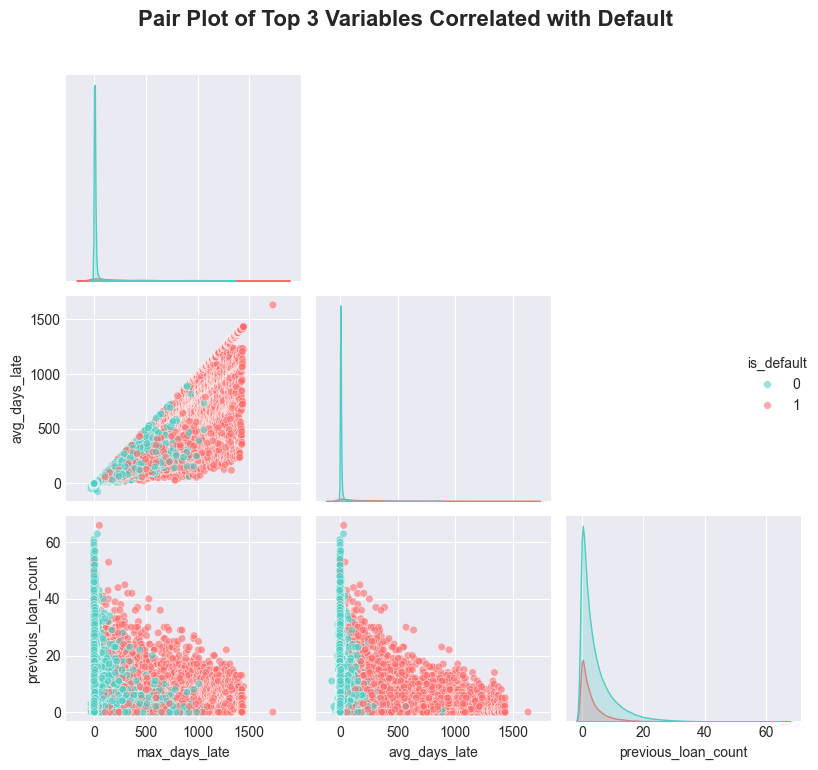

In [26]:
# Select top 3 variables correlated with default
corr_with_default = corr_matrix['is_default'].abs().sort_values(ascending=False).index[1:4]
pair_plot_vars = ['is_default'] + corr_with_default.tolist()

# Create pair plot
plt.figure(figsize=(14, 12))
sns.pairplot(df[pair_plot_vars], 
             hue='is_default',
             palette={0: COLORS['default'][1], 1: COLORS['default'][0]},
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 30},
             corner=True)
plt.suptitle('Pair Plot of Top 3 Variables Correlated with Default', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show();

# Pair Plot Analysis: Top 3 Variables vs. Default

## Visual Observations

The pair plot shows distributions and relationships between:
1. **`max_days_late`**
2. **`avg_days_late`**
3. **`previous_loan_count`**
4. **`is_default`** (target variable: 0 = Non-Default, 1 = Default)

### **Key Patterns (Now Intuitive):**

#### 1. **Diagonal (Distributions)**
- **`max_days_late`**: Highly right-skewed, with most values clustered near 0 but extending beyond 1500 days.
- **`avg_days_late`**: Similarly right-skewed, concentrated near 0 with a long tail.
- **`previous_loan_count`**: Right-skewed, ranging from 0 to ~60 loans, with most borrowers having few previous loans.

#### 2. **Off-Diagonal (Scatter Relationships)**
- **`max_days_late` vs. `avg_days_late`**: Shows a strong positive linear relationship (as expected from correlation ≈ 0.91), confirming high collinearity.
- **`max_days_late` vs. `previous_loan_count`**: No clear linear pattern, suggesting independence between delinquency and loan count.
- **`avg_days_late` vs. `previous_loan_count`**: Similarly, no clear linear trend.


## Interpretation & Business Implications

### **Confirmed Insights:**
1. **High collinearity** between `max_days_late` and `avg_days_late` is visually evident.
2. **Defaulters have significantly higher days late** - clear separation in the scatter plots.
3. **`previous_loan_count` shows weaker discriminatory power** visually.
4. **Non-linear boundaries may exist** - default/non-default separation isn't perfectly linear.

### **Risk Thresholds Visualization:**
- **Default rarely occurs below ~100 `max_days_late`**
- **Most defaults occur above ~200 `max_days_late`**
- **Extreme delinquency (>500 days) is almost exclusively associated with default**

###  **Modeling Considerations:**
- **Linear models should work well** for separating classes using delinquency features.
- **Consider non-linear transformations** for `previous_loan_count` (e.g., log, binning).
- **Feature engineering opportunity**: Create delinquency ratio (`max_days_late`/loan term).

## **Modeling Recommendations:**

1. **Use `max_days_late` as primary feature** (choose over `avg_days_late`)
2. **Consider non-linear terms** for `previous_loan_count` (e.g., squared, log)
3. **Test interaction**: `max_days_late × previous_loan_count`
4. **Create delinquency buckets** for interpretability:
   - 0-30 days: Low risk
   - 31-100 days: Medium risk  
   - 101-200 days: High risk
   - 200+ days: Very high risk

### **Visual Confirmation of Model Logic:**
The pair plot visually validates that a simple rule like **"`max_days_late` > 200"** would correctly identify many defaults while having relatively few false positives among non-defaults.

This visualization provides strong evidence for using delinquency metrics as primary predictors in default risk models.

## 6: Data Preprocessing
### 6.1 Column Datatypes
This dataset mostly contains columns with numerical data. However, based on the domain knowledge and business understanding, the features should be categorized as follows:

**Categorical Features**
* `productid, isloannew, loan_month, gender, has_guarantor`

**Numerical Features**
* `num_late_payments, num_ontime_payments, num_penalties, late_payment_rate, repayment_ratio, total_unpaid_amount, avg_installment_paid, loanamount, loan_term_days, principal, interest_rate, loan_to_limit_ratio, age, account_age_days, loanlimit, graduation_velocity, previous_loan_count, previous_clearance_rate, loan_size_escalation, penalty_rate`

The columns have been converted to the appropriate datatype where necessary.

In [27]:
# features
numerical_cols = ['num_late_payments', 'num_ontime_payments', 'num_penalties', 'late_payment_rate',
                  'repayment_ratio', 'total_unpaid_amount', 'avg_installment_paid', 'loanamount', 'loan_term_days', 'principal',
                  'interest_rate', 'loan_to_limit_ratio', 'age', 'account_age_days', 'loanlimit', 'graduation_velocity', 'previous_loan_count',
                  'previous_clearance_rate', 'loan_size_escalation', 'penalty_rate']
categorical_cols = ['productid', 'isloannew', 'loan_month', 'gender', 'has_guarantor']

# Group data into features and target variable
y = df['is_default']
X = df[numerical_cols + categorical_cols]

# Convert categorical features into object datatype
X[categorical_cols] = X[categorical_cols].astype('object')

main_df = X[categorical_cols+numerical_cols]
main_df.head()

,productid,isloannew,loan_month,gender,has_guarantor,num_late_payments,num_ontime_payments,num_penalties,late_payment_rate,repayment_ratio,...,interest_rate,loan_to_limit_ratio,age,account_age_days,loanlimit,graduation_velocity,previous_loan_count,previous_clearance_rate,loan_size_escalation,penalty_rate
0,30111,0.0,12,2.0,1,0,0,0,0.0,0.0,...,0.270,1.270,35.0,163,9000.0,0.0,5,1.000000,1.360067,0.0
1,30111,0.0,12,2.0,0,0,0,0,0.0,0.0,...,0.270,1.270,38.0,55,10000.0,0.0,2,1.000000,1.250000,0.0
2,30106,1.0,12,2.0,1,0,0,0,0.0,0.0,...,0.435,1.435,38.0,0,5000.0,0.0,0,0.000000,1.000000,0.0
3,30111,0.0,12,2.0,0,0,0,0,0.0,0.0,...,0.270,1.270,38.0,1078,15000.0,0.0,29,1.000000,1.283296,0.0
4,30111,0.0,12,1.0,1,0,0,0,0.0,0.0,...,0.290,1.290,25.0,43,5000.0,0.0,3,0.666666,1.000000,0.0


#### 6.2 Feature Normalization

In [28]:
#Function for splitting data
def split_and_scale_numeric(X,y,numerical_cols,test_size=0.3,random_state=15):
    #split
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size, random_state=random_state, stratify=y)
    #Scaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled = scaler.transform(X_test[numerical_cols])

    # Back to DataFrame
    X_train_scaled = pd.DataFrame(X_train_scaled,columns=numerical_cols,index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled,columns=numerical_cols,index=X_test.index)

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler


X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = (split_and_scale_numeric(X=X, y=y, numerical_cols=numerical_cols))


#### 6.3 One-hot Encoding

In [29]:
# Initialize a one-hot encoder

def encode_categorical(X_train,X_test,categorical_cols):
    ohe = OneHotEncoder(drop='if_binary', sparse_output=False, dtype=int, handle_unknown='ignore' )
 
    X_train_enc = ohe.fit_transform(X_train[categorical_cols])
    X_test_enc = ohe.transform(X_test[categorical_cols])

    feature_names = ohe.get_feature_names_out(categorical_cols)

    X_train_enc = pd.DataFrame( X_train_enc, columns=feature_names, index=X_train.index )
    X_test_enc = pd.DataFrame( X_test_enc, columns=feature_names, index=X_test.index )
    
    return X_train_enc, X_test_enc, ohe

X_train_encoded, X_test_encoded, ohe = encode_categorical(X_train, X_test, categorical_cols)

In [30]:
# Merge the scaled and encoded dataframes
X_train_transformed = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

X_train_transformed.head()

,num_late_payments,num_ontime_payments,num_penalties,late_payment_rate,repayment_ratio,total_unpaid_amount,avg_installment_paid,loanamount,loan_term_days,principal,...,loan_month_5,loan_month_6,loan_month_7,loan_month_8,loan_month_9,loan_month_10,loan_month_11,loan_month_12,gender_2.0,has_guarantor_1
64376,0.126399,-0.801154,2.583484,0.729726,-0.154565,-0.008587,-0.309119,-0.533660,-0.379283,-0.539236,...,0,0,0,0,0,0,0,0,1,1
27001,-0.220588,-0.160526,-0.144071,0.030589,-0.154568,-0.008587,-0.202764,-0.533660,-0.379283,-0.539236,...,0,0,0,1,0,0,0,0,1,1
218443,-0.220588,-1.121468,-0.144071,-0.435503,-0.154567,-0.008587,-1.122865,-0.689038,1.224839,-0.770461,...,0,0,0,0,0,0,1,0,1,1
56354,0.473386,1.120730,-0.144071,0.030589,-0.154568,-0.008587,0.253741,1.474494,2.828962,1.079338,...,0,0,0,0,0,0,0,0,1,0
32434,7.760116,6.566070,-0.144071,1.428864,-0.154568,-0.008587,-1.107332,-0.648841,-0.723023,-0.654849,...,0,0,1,0,0,0,0,0,0,1


#### 6.4 Minotity Class Oversampling Using SMOTE

In [31]:
smote = SMOTE()
X_train_final, y_train_final = smote.fit_resample(X_train_transformed, y_train)

In [32]:
print("Target variable distribution before oversampling:")
print(y_train.value_counts(normalize=True))

print("\n------------------------------------------------")
print("Target variable distribution after oversampling:")
print(y_train_final.value_counts(normalize=True))

Target variable distribution before oversampling:
is_default
0    0.800755
1    0.199245
Name: proportion, dtype: float64

------------------------------------------------
Target variable distribution after oversampling:
is_default
1    0.5
0    0.5
Name: proportion, dtype: float64


## 7: Baseline Models
### 7.1 Logistic Regression Classifier (before oversampling)

In [33]:
def train_evaluate_logreg( X_train, X_test, y_train, y_test, random_state=15, **model_kwargs ):

    model = LogisticRegression(random_state=random_state, **model_kwargs)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Precision": [precision_score(y_train, train_pred),precision_score(y_test, test_pred)],
        "Recall": [recall_score(y_train, train_pred),recall_score(y_test, test_pred)],
        "F1-Score": [f1_score(y_train, train_pred), f1_score(y_test, test_pred)],
        "Accuracy": [accuracy_score(y_train, train_pred),accuracy_score(y_test, test_pred)]
    }

    results = pd.DataFrame(metrics, index=["Train Set", "Test Set"])
    return model, results

In [34]:
# Instantiate a baseline logistic regression model
baseline, baseline_results = train_evaluate_logreg(X_train_transformed, X_test_final, y_train, y_test )

print("Logistic Regression Model Performance Before Oversampling:")
baseline_results

Logistic Regression Model Performance Before Oversampling:


,Precision,Recall,F1-Score,Accuracy
Train Set,0.987583,0.906994,0.945575,0.979197
Test Set,0.986600,0.905511,0.944318,0.978723


### 7.2 Logistic Regression Classifier (after oversampling)

In [35]:
# Instantiating oversampling logistic regression model
oversamplemodel, oversamplemodel_results = train_evaluate_logreg(X_train_final, X_test_final, y_train_final, y_test )

print("Logistic Regression Model Performance After Oversampling:")
oversamplemodel_results

Logistic Regression Model Performance After Oversampling:


,Precision,Recall,F1-Score,Accuracy
Train Set,0.991732,0.951459,0.971178,0.971763
Test Set,0.966220,0.930227,0.947882,0.979618


### 7.3 Comparing the Logistic Regression Models

In [36]:
#Creating function for comparing results
def compare_test_results(*results, labels):
    return pd.DataFrame(
        [{k: r.loc["Test Set", k] for k in r.columns} for r in results],
        index=labels
    )

In [37]:
#Comparing baseline and oversampling
compare_test_results(
    baseline_results,
    oversamplemodel_results,
    labels=["Before Oversampling", "After Oversampling"]
)

,Precision,Recall,F1-Score,Accuracy
Before Oversampling,0.98660,0.905511,0.944318,0.978723
After Oversampling,0.96622,0.930227,0.947882,0.979618


### 7.4 Feature Importance

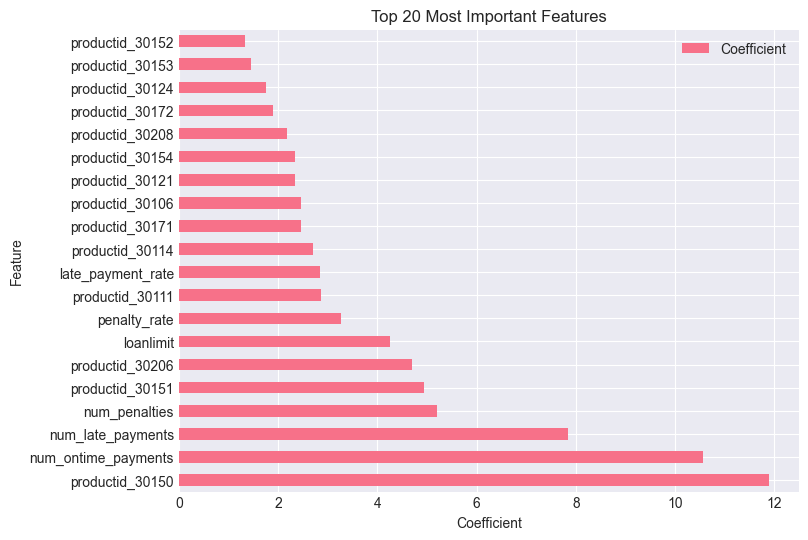

In [38]:
coefficients = baseline.coef_[0]

feature_importance = pd.DataFrame({'Feature': X_train_final.columns, 'Coefficient': coefficients})
feature_importance['Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(8,6))

feature_importance.head(20).plot.barh('Feature', 'Coefficient', ax=ax)
ax.set_title('Top 20 Most Important Features')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Feature');

#### **Key Insights**
* **Precision vs Recall**: For the loan default classifier, it is more useful to the business if majority of the defaulters are correctly classified as so. This will enable the organization to take early action on the defaulters and minimize risks. In this case, achieving a model with high recall will be advantageous.
* **Model Accuracy**: The test set contains 80% of non-defaulted loans and 20% of defaulted loans. Both logistic regression models have achieved an accuracy of ~97%, which is indicative of non-biased models.
* **Effect of Oversampling**: Oversampling generally improved the model performance -- 0.027 increase in recall, 0.007 increase in F1 score and 0.002 increase in accuracy.
* **Feature Importance**: The `loan product`, `number of ontime payments`, `number of penalties`, `loan month` and `number of late payments` are among the important features that are helpful in the prediction of whether a borrower will default or not.
* **Conclusion**: The oversampled dataset improves model performance. This dataset is therefore used in the examination of other advanced classification models.

## 7.5 Handling Multi_Collinearity Using VIF

In [39]:
#computing VIF
def compute_vif(X):
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif.sort_values("VIF", ascending=False)

In [40]:
#Computing VIF on X_train_scaled
vif_df = compute_vif(X_train_scaled)
vif_df

,feature,VIF
9,principal,217.236122
7,loanamount,209.969168
0,num_late_payments,7.292903
10,interest_rate,6.461644
8,loan_term_days,4.602238
19,penalty_rate,4.193061
2,num_penalties,4.187961
6,avg_installment_paid,4.078091
1,num_ontime_payments,3.908690
16,previous_loan_count,3.879987


In [41]:
#dropping Principal
main_df = main_df.drop(columns=['principal'])

### VIF Summary

VIF analysis identified **severe multicollinearity** between `principal` and `loanamount` (VIF > 200) due to their direct mathematical relationship.  
**Action:** `principal` will dropped and `loanamount` retained to remove redundancy and stabilize the model.

Features with **mild multicollinearity** (VIF < 10), such as `num_late_payments` and `interest_rate`, were kept, as this level is acceptable in applied modeling.

All remaining features fall within the **healthy range** (VIF ≈ 1–5), indicating low multicollinearity and a stable feature set.

### 7.6 Baseline Model After VIF

In [42]:
#processing the data
categorical_cols = main_df.select_dtypes(include='object').columns.tolist()

numerical_cols = main_df.select_dtypes(include='number').columns.tolist()
X = main_df
y = y #already defined before
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = (split_and_scale_numeric(X=X, y=y, numerical_cols=numerical_cols))
X_train_encoded, X_test_encoded, ohe = encode_categorical(X_train, X_test, categorical_cols)

# Merge the scaled and encoded dataframes
X_train_vif = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_vif = pd.concat([X_test_scaled, X_test_encoded], axis=1)

X_train_vif.head()

,num_late_payments,num_ontime_payments,num_penalties,late_payment_rate,repayment_ratio,total_unpaid_amount,avg_installment_paid,loanamount,loan_term_days,interest_rate,...,loan_month_5,loan_month_6,loan_month_7,loan_month_8,loan_month_9,loan_month_10,loan_month_11,loan_month_12,gender_2.0,has_guarantor_1
64376,0.126399,-0.801154,2.583484,0.729726,-0.154565,-0.008587,-0.309119,-0.533660,-0.379283,-0.227417,...,0,0,0,0,0,0,0,0,1,1
27001,-0.220588,-0.160526,-0.144071,0.030589,-0.154568,-0.008587,-0.202764,-0.533660,-0.379283,-0.227417,...,0,0,0,1,0,0,0,0,1,1
218443,-0.220588,-1.121468,-0.144071,-0.435503,-0.154567,-0.008587,-1.122865,-0.689038,1.224839,1.081162,...,0,0,0,0,0,0,1,0,1,1
56354,0.473386,1.120730,-0.144071,0.030589,-0.154568,-0.008587,0.253741,1.474494,2.828962,3.415622,...,0,0,0,0,0,0,0,0,1,0
32434,7.760116,6.566070,-0.144071,1.428864,-0.154568,-0.008587,-1.107332,-0.648841,-0.723023,-0.373139,...,0,0,1,0,0,0,0,0,0,1


In [43]:
#Calling Model and results
vif_model, vif_results = train_evaluate_logreg(X_train_vif, X_test_vif, y_train, y_test )

print("Logistic Regression Model Performance (After VIF-based Feature Selection):")
vif_results

Logistic Regression Model Performance (After VIF-based Feature Selection):


,Precision,Recall,F1-Score,Accuracy
Train Set,0.987994,0.905119,0.944743,0.978904
Test Set,0.986961,0.904092,0.943711,0.978511


### 7.7 Baseline Model With Class_Balanced Weights

In [44]:
bal_model, bal_results = train_evaluate_logreg(X_train_vif,
    X_test_vif,y_train,y_test,
    penalty='elasticnet',solver='saga',
    l1_ratio=0.5,class_weight='balanced',max_iter=5000)

print("Logistic Regression Model Performance (Balanced ElasticNet):")
bal_results

Logistic Regression Model Performance (Balanced ElasticNet):


,Precision,Recall,F1-Score,Accuracy
Train Set,0.944750,0.932539,0.938605,0.975693
Test Set,0.946011,0.932474,0.939194,0.975943


#### Impact of Class-Balanced ElasticNet Logistic Regression

Introducing class balancing and ElasticNet regularization led to a more effective and robust model.  
While overall accuracy remained high and largely unchanged, the **balanced ElasticNet model achieved a clear improvement in recall**, indicating a stronger ability to identify defaulters.

Compared to the VIF-based logistic regression, recall increased from approximately **0.90 to 0.93** on both the training and test sets, reflecting better sensitivity to the minority class. Precision decreased slightly but remained high, resulting in a **more balanced precision–recall trade-off**.

Overall, the balanced ElasticNet model provides improved detection of default cases without sacrificing overall model stability or generalization.


## 8: Advanced Models

In [45]:
#Aggregating Data
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = (split_and_scale_numeric(X=X, y=y, numerical_cols=numerical_cols))
X_train_encoded, X_test_encoded, ohe = encode_categorical(X_train, X_test, categorical_cols)

# Merge the scaled and encoded dataframes
X_train_final = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

X_train_os, y_train_os = smote.fit_resample(X_train_final, y_train)

In [46]:
#Asserting 
assert X_train_final.shape[0] == y_train.shape[0]
assert X_test_final.shape[0] == y_test.shape[0]
assert X_train_final.shape[1] == X_test_final.shape[1]

#Oversampled training set
assert X_train_os.shape[0] == y_train_os.shape[0]
assert X_train_os.shape[1] == X_train_final.shape[1]

This model is designed for risk assessment of borrowers with existing repayment history.
It leverages historical payment behavior to identify high-risk accounts for early intervention,
rather than predicting default at loan origination for new customers.

### Models Choosen
🔹 **Random Forest**

    Why: Captures nonlinear interactions, Robust to noisy features & Strong with behavioral data

🔹 **LightGBM**

    Why: Employed to model complex non-linear interactions in repayment behavior

### Random Forest

In [47]:
#creating model pipelin
def train_evaluate_rf( X_train, X_test, y_train, y_test, random_state=15, **model_kwargs):

    model = RandomForestClassifier(
        random_state=random_state,n_jobs=-1,**model_kwargs)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Precision": [precision_score(y_train, train_pred),precision_score(y_test, test_pred)],
        "Recall": [recall_score(y_train, train_pred),recall_score(y_test, test_pred)],
        "F1-Score": [f1_score(y_train, train_pred),f1_score(y_test, test_pred)],
        "Accuracy": [accuracy_score(y_train, train_pred),accuracy_score(y_test, test_pred)]
    }

    results = pd.DataFrame(metrics, index=["Train Set", "Test Set"])
    return model, results

### 8.1: Baseline Random Forest (No oversampling)

In [48]:
#baseline model definition
baseline_rf, baseline_rf_results = train_evaluate_rf(
    X_train_final,X_test_final,
    y_train, y_test,
    n_estimators=300,max_depth=None,min_samples_leaf=20
)

print("Random Forest Model Performance (Baseline):")
baseline_rf_results

Random Forest Model Performance (Baseline):


,Precision,Recall,F1-Score,Accuracy
Train Set,0.989290,0.992499,0.990892,0.996365
Test Set,0.987979,0.991367,0.989670,0.995877


The baseline Random Forest model achieved exceptionally high performance on both the training and test sets, with **F1-scores** close to **0.99** and minimal performance gap between the two. This indicates **strong generalization** and suggests that the model effectively captures non-linear relationships and feature interactions present in the data. The consistently **high recall** demonstrates the model’s strong ability to identify default cases, making it particularly suitable for historical borrower risk assessment and monitoring tasks.

### 8.2: Random Forest with Class Imbalance Handling

In [49]:
#Class Balanced model definition
class_balanced_rf, class_balanced_rf_results = train_evaluate_rf(
    X_train_final,X_test_final,
    y_train, y_test,
    n_estimators=300, min_samples_leaf=20,
    class_weight='balanced')

print("Random Forest Model Performance (Class-Balanced):")
class_balanced_rf_results

Random Forest Model Performance (Class-Balanced):


,Precision,Recall,F1-Score,Accuracy
Train Set,0.986515,0.997415,0.991935,0.996768
Test Set,0.985241,0.994678,0.989937,0.995971


The **Class-balanced Random Forest** model further improved **recall** on both the training and test sets while maintaining high **precision** and overall accuracy. This indicates that incorporating class weighting helps the model better emphasize minority-class (default) instances without sacrificing generalization performance. The results confirm the robustness of Random Forest to class imbalance and its suitability for post-disbursement default risk monitoring.

### 8.3: Random Forest with Oversampling

In [50]:
#model with oversampling
oversample_rf, oversample_rf_results = train_evaluate_rf(
    X_train_os, X_test_final,
    y_train_os,y_test,
    n_estimators=300,min_samples_leaf=20
)

print("Random Forest Model Performance (After Oversampling):")
oversample_rf_results

Random Forest Model Performance (After Oversampling):


,Precision,Recall,F1-Score,Accuracy
Train Set,0.997206,0.999067,0.998135,0.998134
Test Set,0.988010,0.993969,0.990980,0.996395


The Random Forest model trained on oversampled data achieved the **strongest overall performance**, with very high **recall** and **F1-score** on both the training and test sets. Oversampling further improved the model’s sensitivity to default cases while maintaining strong precision and accuracy, indicating effective learning from the balanced training distribution. The small train–test performance gap suggests that the model generalizes well and benefits from oversampling in this historical borrower setting.

### 8.4: Feature Importance

In [51]:
#Creating Feature Importance
rf_importance = pd.Series(oversample_rf.feature_importances_,index=X_train_final.columns).sort_values(ascending=False)

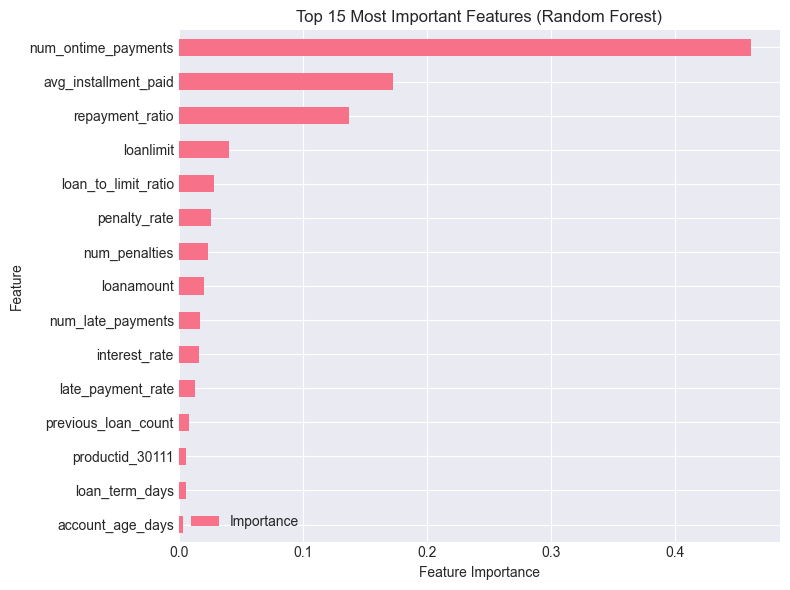

In [52]:
#Visualizing
rf_feature_importance = pd.DataFrame({'Feature': X_train_final.columns, 'Importance': oversample_rf.feature_importances_})
rf_feature_importance = rf_feature_importance.sort_values('Importance',ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
rf_feature_importance.head(15).plot.barh(x='Feature',y='Importance',ax=ax)

ax.set_title('Top 15 Most Important Features (Random Forest)')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

The Random Forest feature importance analysis shows that repayment behavior variables dominate the model’s predictions. Features such as `num_ontime_payments`, `avg_installment_paid`, and `repayment_ratio` are the strongest drivers of default risk, highlighting the importance of consistent repayment patterns. Credit capacity indicators, including `loanlimit` and `loan_to_limit_ratio`, also contribute meaningfully, while loan terms and demographic variables play a comparatively smaller role.

Overall, the results confirm that the model primarily relies on observed repayment behavior, reinforcing its suitability for post-disbursement risk monitoring rather than pure loan origination scoring.

### LightGBM

LightGBM (Light Gradient Boosting Machine) is a high-performance gradient boosting framework that builds decision trees in a leaf-wise manner, enabling efficient learning of complex non-linear patterns in large tabular datasets.

Why LightGBM:

    Trees are built one after another

    Each tree learns from the errors (gradients) of the previous trees

    This produces very strong predictive models

Compared to Random Forest:

    RF → trees built independently

    LightGBM → trees built iteratively to reduce error
    
Most tree models grow level-wise:

        Root
       /    \
     L1      L1
    /  \    /  \

LightGBM grows leaf-wise: 

     Root
           \
            Leaf (best split)
                \
                 Leaf

Reduces loss faster

Captures complex patterns

Needs fewer trees,Memory efficient,Faster than Random Forest,100k+ rows & Many features

In [53]:
#creating lgbm pipeline
def train_evaluate_lgbm(X_train, X_test,y_train, y_test, random_state=15, **model_kwargs):
    
    model = lgb.LGBMClassifier(random_state=random_state,n_jobs=-1,**model_kwargs)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Precision": [precision_score(y_train, train_pred),precision_score(y_test, test_pred)],
        "Recall": [ recall_score(y_train, train_pred), recall_score(y_test, test_pred) ],
        "F1-Score": [ f1_score(y_train, train_pred), f1_score(y_test, test_pred) ],
        "Accuracy": [ accuracy_score(y_train, train_pred), accuracy_score(y_test, test_pred) ]
    }

    results = pd.DataFrame(metrics, index=["Train Set", "Test Set"])
    return model, results

### 8.5: Baseline LightGBM (No oversampling)

In [54]:
baselinelgb, baselinelgb_results = train_evaluate_lgbm(
    X_train_final, X_test_final,
    y_train,y_test,
    n_estimators=500,learning_rate=0.05,
    num_leaves=31,min_data_in_leaf=50
    )

print("LightGBM Model Performance (Baseline):")
baselinelgb_results

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 19730, number of negative: 79294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 99024, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199245 -> initscore=-1.391022
[LightGBM] [Info] Start training from score -1.391022
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will b

,Precision,Recall,F1-Score,Accuracy
Train Set,0.999949,0.999949,0.999949,0.99998
Test Set,0.995165,0.997871,0.996516,0.99861


### 8.6: Class-balanced LightGBM 

In [55]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

balancedlgb, balancedlgb_results = train_evaluate_lgbm(
    X_train_final,X_test_final,
    y_train,y_test,
    n_estimators=500,learning_rate=0.05,
    num_leaves=31,min_data_in_leaf=50,
    scale_pos_weight=scale_pos_weight
)

print("LightGBM Model Performance (Class-Balanced):")
balancedlgb_results

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 19730, number of negative: 79294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 99024, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199245 -> initscore=-1.391022
[LightGBM] [Info] Start training from score -1.391022
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will b

,Precision,Recall,F1-Score,Accuracy
Train Set,0.999899,1.000000,0.999949,0.999980
Test Set,0.994462,0.998108,0.996282,0.998516


### 8.7: LightGBM after SMOTE

In [57]:
#LightGBM 
oversamplelgb, oversamplelgb_results = train_evaluate_lgbm(
    X_train_os,X_test_final,
    y_train_os,y_test,
    n_estimators=500,learning_rate=0.05,
    num_leaves=31,min_data_in_leaf=50
    )

print("LightGBM Model Performance (After Oversampling):")
oversamplelgb_results

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 79294, number of negative: 79294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4328
[LightGBM] [Info] Number of data points in the train set: 158588, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
LightGBM

,Precision,Recall,F1-Score,Accuracy
Train Set,0.999987,0.999987,0.999987,0.999987
Test Set,0.994929,0.997753,0.996339,0.998539


### 8.8: LightGBM SHAP Interpretability

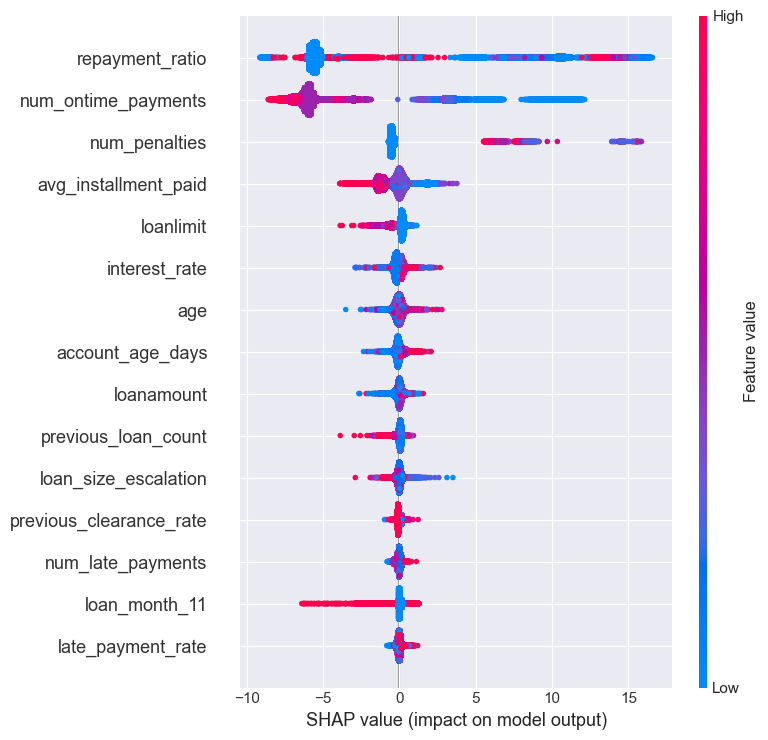

In [58]:
import shap

explainer = shap.TreeExplainer(oversamplelgb)
shap_values = explainer.shap_values(X_train_final)
shap.summary_plot(shap_values[1],X_train_final,max_display=15)

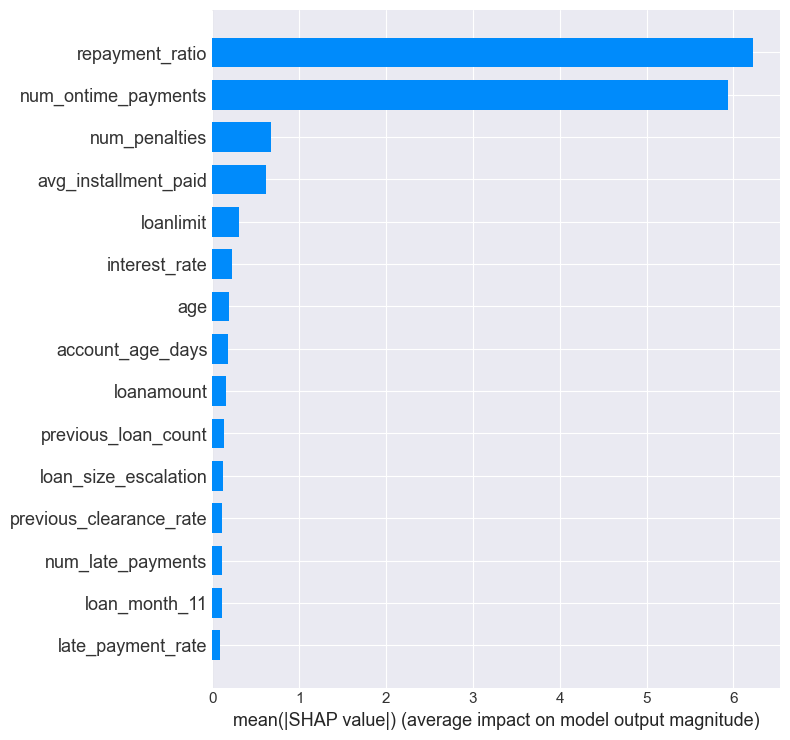

In [59]:
#feature importance
shap.summary_plot(shap_values[1],X_train_final,plot_type="bar",max_display=15)

### 9. RECOMMENDATIONS 
Based on the exploratory analysis and the performance of the predictive models, the following recommendations are proposed to improve credit risk management for SMEs and youth entrepreneurs:

**1. Adoption of Machine Learning-Based Credit Scoring**
Financial institutions should adopt machine learning-based credit scoring systems instead of relying solely on traditional rule-based or manual credit assessments. The models developed in this study demonstrate the borrower charactristics such as income, credit history, employment status, and loan amount are important predictors of default. Using these models can improve the accuracy of loan approval decisions and reduce default rates.

**2. Risk-Based Borrower Segmentation**
Rather than treating all borrowers equally, lenders should classify applicants into different risk categories such as low, medium, and high-risk based on the predicted probability of default. This would allow institutions to:
- Offer lower interest rates and higher loan limits to low-risk borrowers,
- Apply stricter conditions or higher interest rates to medium-risk borrowers, and
- Limit exposure to high-risk borrowers or require additional guarantees.
This approach supports both financial inclusion and portfolio sustainability.

**3. Use of the Model as an Early Warning System**
The predictive model should not only be used at the loan approval stage but also during the loan repayment period. By periodically updating borrower data, the institution can identify customers whose risk of default is increasing and take early action such as sending reminders, offering financial guidance, or restructuring loans. This can help reduce non-performing loans.

**4. Integration with Human Decision-Making**
Although the model provides valuable insights, it should be used as a decision-support tool rather than a complete replacement for loan officers. Human judgement is still important, especially for borderline cases or for assessing qualitative factors such as business viability and local market conditions.

**5. Continuous Model Improvement**
The accuracy of the model can be further improved by incorporating more detailed borrower information, such as business cashflows, mobile money transaction history, and past repayment behavior. Regular retraining of the model with new data will also ensure that it remains relevant and reliable over time.
